# Toxic Language Detection Using Deep Learning: A Comparative Study with Explainability and Robustness Analysis

## 0. Imports and Reproducibility

This section defines the required libraries and ensures reproducibility by fixing random seeds. This helps guarantee that experimental results are consistent across runs.

In [141]:
import os
import seaborn as sns
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from wordcloud import WordCloud
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from transformers import DistilBertTokenizer
from transformers import DistilBertModel

from captum.attr import LayerIntegratedGradients

from lime.lime_text import LimeTextExplainer

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warnings.filterwarnings("ignore")

In [2]:
import torch

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## 1. Introduction

### 1.1 Problem Statement: The Nuance of Digital Toxicity

As the volume of user-generated content continues to grow, online platforms have become increasingly vulnerable to toxic behaviour. This includes insults, harassment, threats, obscene language, and identity-based hate speech. Unlike spoken conversation, digital text can be disseminated instantly and at large scale, amplifying the reach and potential harm of abusive language.

A central challenge in toxic language detection is that **human language is inherently nuanced**. Expressions that appear harmless in one context may be offensive in another, while some users deliberately obscure toxic intent through sarcasm, slang, misspellings, or coded language. As a result, toxicity detection is not a simple keyword-matching problem, but a complex task requiring contextual and semantic understanding of language (Schmidt & Wiegand, 2017).

---

### 1.2 Motivation and Justification

The importance of automated toxic language detection can be justified in several ways.

First, maintaining safe and constructive online communities requires timely identification and moderation of harmful content. Second, the sheer scale of online communication makes fully manual moderation infeasible. Human moderators cannot realistically review all content, and prolonged exposure to toxic material can have significant psychological consequences.

Automated systems can therefore act as a first line of defence, filtering large volumes of content and allowing human moderators to focus on ambiguous or high-risk cases. Additionally, machine learning models offer the ability to apply learned decision patterns consistently across large datasets. However, such systems must also be critically evaluated, as they may reflect biases or inconsistencies present in the training data (Dixon et al., 2018).

---

### 1.3 Objective of the Study

The objective of this project is to develop and compare multiple models for the automated detection of toxic language in text. The task is formulated as a **multi-label text classification problem**, in which each comment may be associated with multiple toxicity categories simultaneously (e.g., *toxic*, *insult*, *threat*).

This problem is particularly challenging because toxicity is not solely determined by explicit lexical features (e.g., offensive words), but also by **contextual and semantic relationships**. A word that is considered toxic in one sentence may be neutral in another, depending on intent and phrasing. Traditional rule-based systems and shallow machine learning approaches can capture strong lexical patterns, but often struggle with context-dependent or implicit toxicity.

To address these challenges, this study follows a structured experimental workflow (Chollet, 2021), progressing from simple baselines to more advanced deep learning and transformer-based models. In addition to predictive performance, the study also examines model robustness, class imbalance effects, failure cases, and model interpretability, with the aim of understanding which features or tokens contribute most to toxicity predictions. This is particularly important in sensitive applications such as content moderation, where model decisions must be examined critically rather than treated as opaque outputs (Ribeiro et al., 2016).

---

### 1.4 Research Questions

This study is guided by the following research questions:

- **RQ1:** How do simple baseline methods compare with deep learning models in multi-label toxic language detection?

- **RQ2:** Do recurrent neural networks (e.g., LSTM, BiLSTM) improve performance over traditional text classification approaches?

- **RQ3:** Does a transformer-based model (DistilBERT) significantly outperform classical deep learning models?

- **RQ4:** How does class imbalance affect performance, particularly for rare labels such as *threat* and *severe_toxic*?

- **RQ5:** How robust are the models to modified or disguised toxic language (e.g., misspellings, sarcasm, obfuscation)?

- **RQ6:** What insights can be gained from analysing model predictions and failure cases?

- **RQ7:** To what extent are model predictions interpretable, and do models rely on meaningful linguistic patterns when identifying toxic language?

---

### 1.5 Success Metrics and Evaluation Strategy

To evaluate model performance in this multi-label classification setting, multiple metrics are used.

The primary evaluation metric is **macro-averaged F1 score**, which gives equal importance to each class and is therefore well-suited to imbalanced datasets. In addition, **micro-averaged F1 score** is reported to capture overall performance across all predictions.

Per-label F1 scores are also examined to better understand how models perform on individual categories, particularly rare and challenging classes. Precision and recall are analysed to study trade-offs between false positives and false negatives.

This multi-metric evaluation approach ensures that performance is assessed not only globally, but also at the level of individual toxicity categories, providing a more comprehensive understanding of model behaviour.

---

### 1.6 Contributions of this Study

This project makes the following contributions:

- A systematic comparison of baseline, recurrent, and transformer-based models for multi-label toxic language detection.
- A structured hyperparameter investigation using reproducible experimental workflows.
- An analysis of class imbalance and its impact on model performance.
- A robustness study examining model behaviour under perturbed or disguised toxic inputs.
- A qualitative analysis of model failures and interpretability insights.
- An interpretability study examining which features and tokens contribute most to model predictions.

Together, these contributions aim to provide a comprehensive understanding of both the capabilities and limitations of modern approaches to toxic language detection.

---

## 2. Dataset and Exploratory Data Analysis

### 2.1 Dataset Description

This study uses the [Jigsaw Toxic Comment Classification dataset](https://www.kaggle.com/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/data), originally released as part of a Kaggle competition. The dataset consists of user-generated comments from online platforms, primarily Wikipedia discussions, annotated for multiple types of toxic behaviour.

Each comment is associated with six binary labels:

- *toxic*
- *severe_toxic*
- *obscene*
- *threat*
- *insult*
- *identity_hate*

Unlike traditional classification tasks, this dataset represents a **multi-label problem**, where a single comment may belong to multiple categories simultaneously. For example, a comment may be both *toxic* and *insulting*, or *toxic* and *identity_hate*.

This multi-label nature introduces additional complexity, as models must learn to identify overlapping and co-occurring forms of toxicity rather than assigning a single class label.


### 2.2 Data Loading and Initial Inspection

The dataset was loaded from a local CSV file and inspected to understand its structure and contents.

Initial inspection shows that each row corresponds to a single comment, along with multiple binary labels indicating different types of toxic behaviour. The dataset contains one primary text field (`comment_text`) and six label columns.

Basic inspection of the dataset confirms:
- the presence of textual data of varying length and complexity
- binary labels for each toxicity category
- a large number of samples suitable for training machine learning models

This step ensures that the dataset is correctly structured and ready for further analysis.

In [3]:
DATA_DIR = Path("./data")
train_path = DATA_DIR / "train.csv"

df = pd.read_csv(train_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


#### Drop the id column
The dataset includes an identifier column (`id`), which does not carry predictive information for the task. This column was removed to avoid introducing irrelevant features into the modeling pipeline.

In [4]:
df = df.drop(columns=["id"])
print(df.columns)

Index(['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='object')


### 2.3 Exploratory Data Analysis (EDA)

#### 2.3.1 Data Integrity: Null and Duplicate Analysis
The dataset must be audited for missing values and duplicate entries. 
**Null values** in text columns can cause vectorization layers to crash, while **duplicate comments**(often caused by "spamming" or bot activity) can lead to data leakage and artificially inflated performance metrics if the same comment appears in both the training and validation sets.


In [5]:
# Check for missing values
null_counts = df.isnull().sum()
print("Null values per column:\n", null_counts)

# Check for duplicate comments
duplicates = df.duplicated(subset=['comment_text']).sum()
print(f"\nNumber of duplicate comments found: {duplicates}")

Null values per column:
 comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Number of duplicate comments found: 0


#### 2.3.2 Class Distribution Analysis
This section quantifies the frequency of each of the six toxicity labels within the training set along with the clean comments.

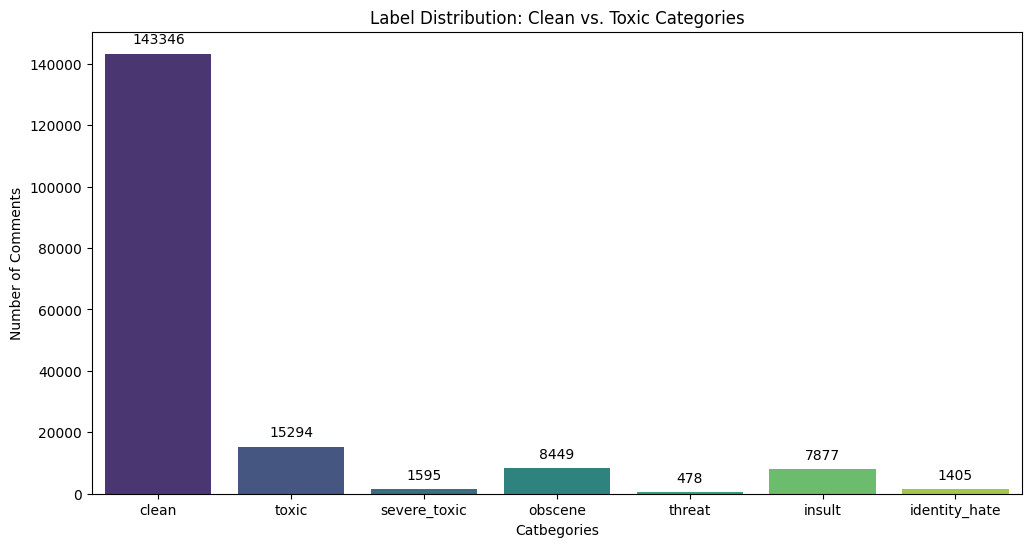

In [6]:
# 1. Define the toxic categories
categories = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# 2. Identify "Clean" comments (where the sum of all toxic labels is 0)
df['clean'] = (df[categories].sum(axis=1) == 0).astype(int)

# 3. Create a combined list for the bar chart
all_labels = ['clean'] + categories
label_counts = df[all_labels].sum()

# 4. Plotting
plt.figure(figsize=(12, 6))
# Using a log scale (optional) can help if the toxic bars are too small to see next to clean
ax = sns.barplot(
    x=label_counts.index, 
    y=label_counts.values, 
    hue=label_counts.index, 
    palette='viridis',
    legend=False
)

# Adding text labels on top of bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Label Distribution: Clean vs. Toxic Categories')
plt.xlabel('Catbegories')
plt.ylabel('Number of Comments')
plt.show()

**Based on the "Distribution of Toxicity Labels" Bar Chart:**

The bar chart reveals a severe **class imbalance** and a sparse labeling structure.
Out of the approximately 160,000 samples, only a small fraction carries toxic labels, with "threat" being the rarest (fewer than 1,000 instances).

While the `Toxic` label is the most frequent among the categories, it still only represents approximately 10% of the total dataset. The remaining 90% of the observations are `clean`. Furthermore, there is an `intra-class imbalance`; for instance, the `Toxic` class has nearly 30 times more samples than the `Threat` class, making the detection of rare labels like threats a major challenge for the model.

**Technical Implication:** This confirms that `Accuracy` is a flawed metric for this project. If the model predicted `clean` for every single comment, it would achieve nearly 90% accuracy while failing its primary purpose.

This observation motivates the use of evaluation metrics such as **macro-averaged F1 score**, which gives equal importance to each class, as well as later experiments involving class weighting.

---

#### 2.3.3 Multi-label nature
An important characteristic of this dataset is that comments may be associated with multiple toxicity labels simultaneously.

Analysis of the number of labels per comment shows that while many comments are non-toxic, a subset contains multiple forms of toxicity. This reinforces the need for a **multi-label classification approach**, rather than reducing the problem to a binary task.

It also suggests that certain types of toxicity frequently co-occur, which may influence model learning and evaluation.

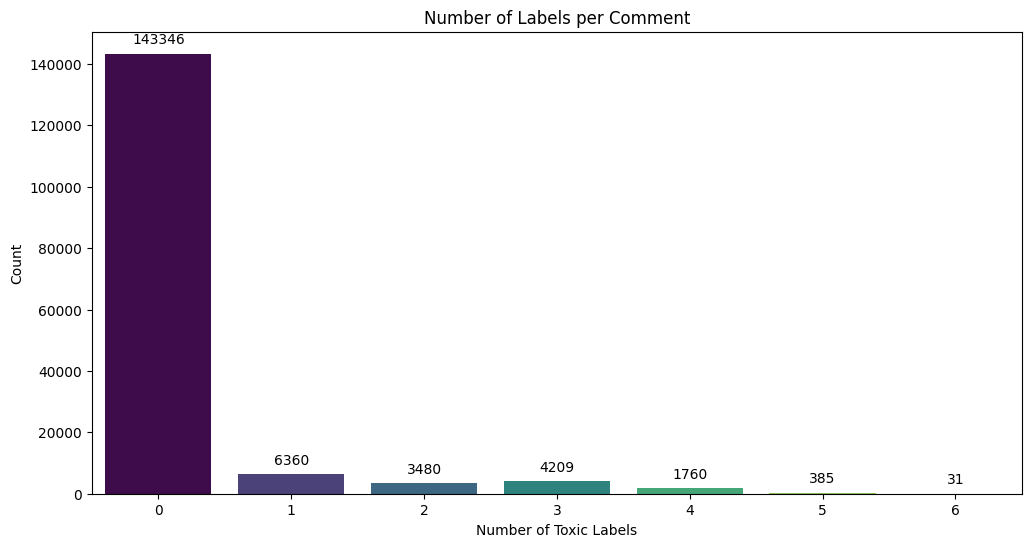

In [7]:
df["num_labels"] = df[categories].sum(axis=1)
values = df["num_labels"].value_counts()

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=values.index, 
    y=values.values, 
    hue=values.index, 
    palette='viridis',
    legend=False
)

# Adding text labels on top of bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title("Number of Labels per Comment")
plt.xlabel("Number of Toxic Labels")
plt.ylabel("Count")
plt.show()

#### 2.3.4 Sequence Length Distribution
Text data varies significantly in length, which presents a challenge for neural networks that require fixed-size input tensors. In this section, we analyze the distribution of word counts across the corpus. This data-driven approach allows us to determine an optimal "cutoff" point for sequence padding and truncation. This ensures we retain maximum information from long comments while minimizing the computational overhead of processing excessive empty space (padding).

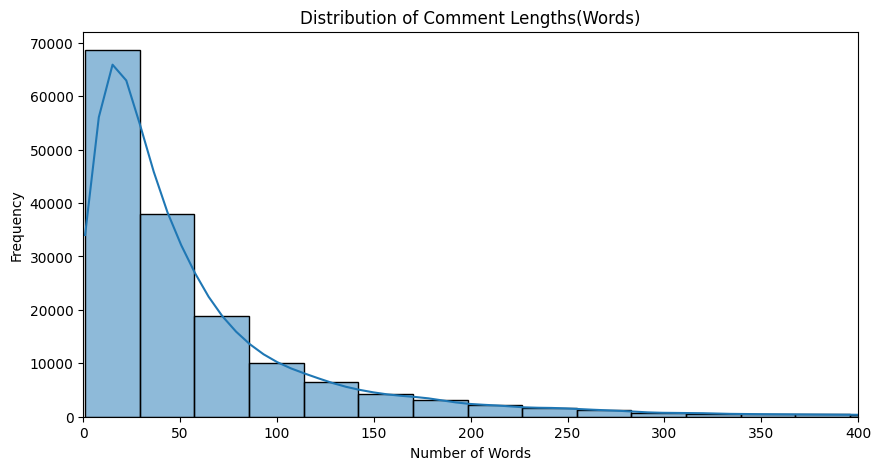

In [8]:
df["comment_length"] = df["comment_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(df['comment_length'], bins=50, kde=True)
plt.title("Distribution of Comment Lengths(Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.xlim(0, 400) # Focusing on the bulk of the data
plt.show()

The distribution of comment lengths exhibits a strongly right-skewed pattern, with the majority of comments concentrated between approximately 20 and 30 words. The frequency decreases rapidly for longer comments, with relatively few instances exceeding 100 words and only a small number approaching extreme lengths.

This distribution has important implications for model design. Processing all comments at their maximum length would introduce unnecessary computational overhead and excessive padding, which can negatively impact training efficiency. Based on this observation, selecting a maximum sequence length of approximately 200 tokens represents a practical trade-off, capturing the vast majority of comments while maintaining computational efficiency.

This decision is particularly relevant for sequence-based models such as **LSTM and transformer architectures**, where input length directly affects both memory usage and training time.

---

#### 2.3.5 Sample Inspection

Manual inspection of example comments reveals several important characteristics of the dataset.

First, many toxic comments contain explicit abusive language, making them relatively easy to detect. However, other examples are more subtle, involving sarcasm, indirect hostility, or context-dependent meaning.

Additionally, some comments include creative spellings or variations designed to obscure offensive intent. These observations highlight the limitations of simple keyword-based approaches and motivate the use of more advanced models capable of capturing contextual and semantic information.



In [9]:
for categroy in categories:
    print(f"\n--- {categroy.upper()} EXAMPLES ---")
    samples = df[df[categroy] == 1]["comment_text"].head(2).tolist()
    for s in samples:
        print("-", s[:300], "\n")


--- TOXIC EXAMPLES ---
- COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK 

- Hey... what is it..
@ | talk .
What is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIAL and DESTRUCTIVE (non)-contribution at WP?

Ask Sityush to clean up his behavior than issue me nons 


--- SEVERE_TOXIC EXAMPLES ---
- COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK 

- Stupid peace of shit stop deleting my stuff asshole go die and fall in a hole go to hell! 


--- OBSCENE EXAMPLES ---
- COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK 

- You are gay or antisemmitian? 

Archangel WHite Tiger

Meow! Greetingshhh!

Uh, there are two ways, why you do erased my comment about WW2, that holocaust was brutally slaying of Jews and not gays/Gypsys/Slavs/anyone...

1 - If you are anti-semitian, than shave your head bald and go to the skinhead  


--- THREAT EXAMPLES ---
- Hi! I am back again!
Last warning!
Stop u

#### 2.3.6 N-gram Analysis (Bi-grams & Tri-grams)
While unigram analysis (single words) often captures noise, N-gram analysis reveals the phrases and linguistic structures common to toxic discourse. By examining sequences of two words (bi-grams) and three words (tri-grams), we can identify "toxic patterns." This analysis provides the strongest justification for using Recurrent Neural Networks (RNNs) or LSTMs, as these architectures are specifically designed to learn the sequential dependencies identified in these phrases.

In [10]:
def get_top_ngrams(corpus, n, g):
    vec = CountVectorizer(ngram_range=(g, g), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

# Filter for only toxic comments to see the "Patterns"
toxic_comments = df[df['toxic'] == 1]['comment_text']

print("Top 10 Toxic Bi-grams:")
for i, (ngram, freq) in enumerate(get_top_ngrams(toxic_comments, 10, 2), 1):
    print(f"{i:2d}. {ngram:<30} → {freq}")
print("\n" + "="*50 + "\n")
print("\nTop 10 Toxic Tri-grams:")
for i, (ngram, freq) in enumerate(get_top_ngrams(toxic_comments, 10, 3), 1):
    print(f"{i:2d}. {ngram:<30} → {freq}")

Top 10 Toxic Bi-grams:
 1. fuck fuck                      → 2959
 2. nigger nigger                  → 2149
 3. hate hate                      → 1570
 4. moron hi                       → 1474
 5. hi moron                       → 1472
 6. pig pig                        → 1250
 7. jew fat                        → 1234
 8. fat jew                        → 1226
 9. shit shit                      → 1149
10. suck suck                      → 1136



Top 10 Toxic Tri-grams:
 1. fuck fuck fuck                 → 2825
 2. nigger nigger nigger           → 2139
 3. hate hate hate                 → 1547
 4. hi moron hi                    → 1468
 5. moron hi moron                 → 1466
 6. pig pig pig                    → 1248
 7. fat jew fat                    → 1226
 8. jew fat jew                    → 1224
 9. ass ass ass                    → 1124
10. suck suck suck                 → 1116


The n-gram analysis reveals several notable patterns in the structure of toxic language within the dataset.

- First, many of the most frequent bi-grams and tri-grams consist of repeated tokens (e.g., repeated offensive terms). This suggests that a portion of toxic content is characterized by repetitive emphasis, where harmful language is intensified through duplication. Such patterns may reflect low-effort or highly aggressive forms of expression.

- Second, certain frequent phrases indicate that toxic language is often directed toward specific identity groups. This observation supports the inclusion of dedicated categories such as *identity_hate* and highlights the targeted nature of some toxic content.

- From a modeling perspective, these findings indicate that the presence and frequency of certain lexical patterns are strong predictive signals. However, they also suggest a potential limitation: models may become overly reliant on explicit keywords and struggle with more subtle or context-dependent forms of toxicity.

These observations motivate the use of sequence-based models, such as **LSTM or transformer architectures**, which are better suited to capturing contextual relationships and the intensity of repeated expressions compared to **simple bag-of-words representations**.

---

#### 2.3.7 Comparative Word Clouds
Word clouds were generated to provide a high-level comparison between the linguistic profiles of "Clean" and "Toxic" comments. This visualization helps identify if specific "anchor words" exist that the neural network can use to distinguish between classes.

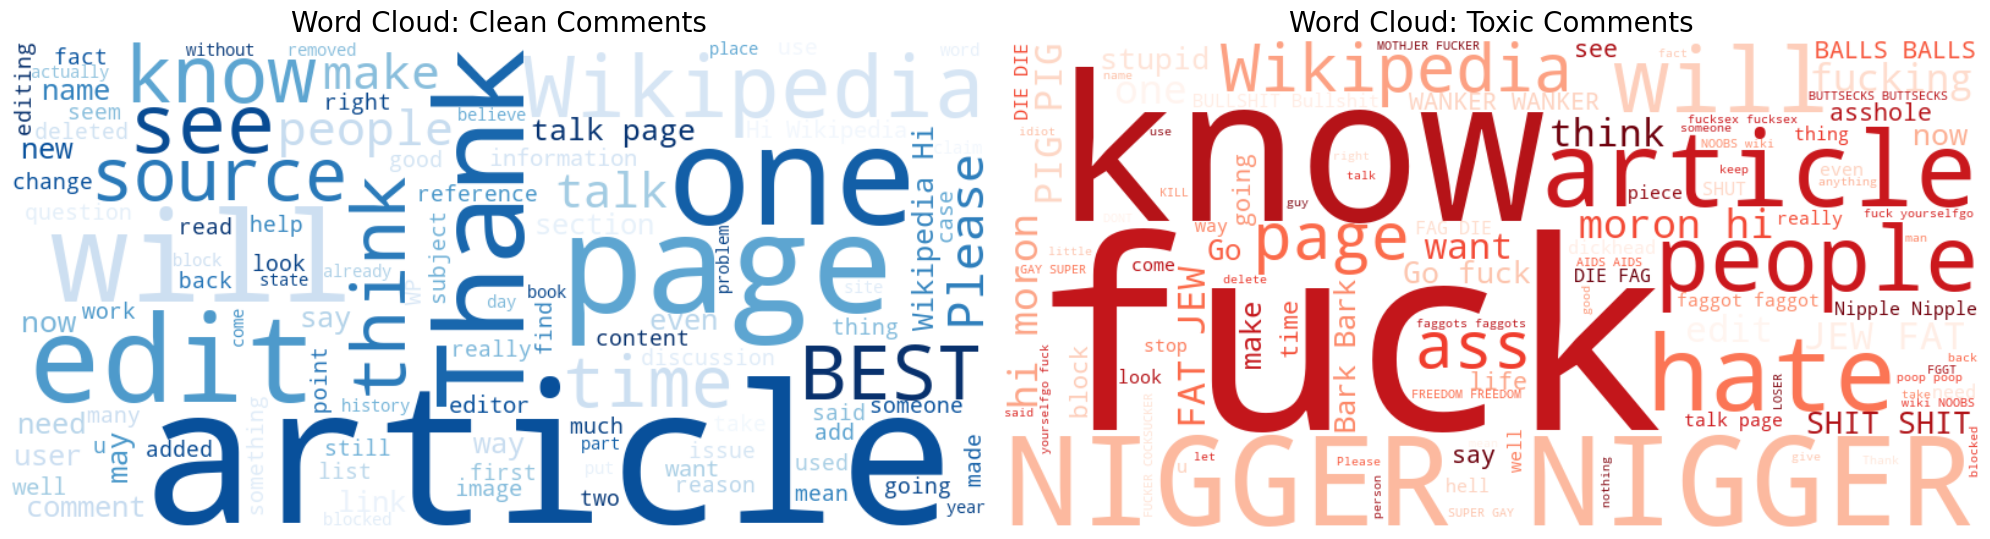

In [11]:
def generate_wordcloud(text, colormap='magma', max_words=100):
    return WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap=colormap,
                          max_words=max_words).generate(text)
    

# Prepare text
clean_text = ' '.join(df[df['clean'] == 1]['comment_text'].sample(5000))
toxic_text = ' '.join(df[df['toxic'] == 1]['comment_text'])

# Create WordClouds
wc_clean = generate_wordcloud(clean_text, colormap='Blues')
wc_toxic = generate_wordcloud(toxic_text, colormap='Reds')

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Clean Comments
axes[0].imshow(wc_clean, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud: Clean Comments', fontsize=20)

# Toxic Comments
axes[1].imshow(wc_toxic, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud: Toxic Comments', fontsize=20)

plt.tight_layout()
plt.show()

- **The "Clean" Semantic Space:** The cloud for clean comments is dominated by Wikipedia-centric nouns and constructive verbs: "article," "page," "edit," "talk," "think," and "thank." This indicates that non-toxic discourse is largely focused on the functional aspects of the platform and follows a collaborative tone.

- **The "Toxic" Semantic Space:** The toxic cloud is characterized by a high density of profanity, slurs, and aggressive verbs. Notably, words like "nigger," "jew," and "fat" appear prominently, confirming that toxicity is often targeted toward specific identity groups (validating the identity_hate category).
---

#### 2.2.8 Lexical Diversity: Unique Word Analysis
This section calculates the ratio of unique tokens to the total number of words (Type-Token Ratio) across the dataset. Analyzing unique words helps determine the necessary size of the embedding vocabulary and identifies whether toxic language is linguistically diverse or repetitive.

Lexical diversity is measured using the Type-Token Ratio (TTR), defined as:

$$
TTR = \frac{\text{Number of Unique Words}}{\text{Total Number of Words}}
$$


In [12]:
def calculate_lexical_diversity(text_series):
    words = ' '.join(text_series).lower().split()
    total_words = len(words)
    unique_words = len(set(words))
    diversity_ratio = unique_words / total_words
    return unique_words, diversity_ratio

# Analyze Clean vs Toxic
unique_c, ratio_c = calculate_lexical_diversity(df[df['clean'] == 1]['comment_text'])
unique_t, ratio_t = calculate_lexical_diversity(df[df['toxic'] == 1]['comment_text'])

print(f"Clean Comments - Unique Words: {unique_c} | Diversity Ratio: {ratio_c:.4f}")
print(f"Toxic Comments - Unique Words: {unique_t} | Diversity Ratio: {ratio_t:.4f}")
print(f"Total Unique Words in Entire Dataset: {len(set(' '.join(df['comment_text']).lower().split()))}")

Clean Comments - Unique Words: 445710 | Diversity Ratio: 0.0451
Toxic Comments - Unique Words: 62131 | Diversity Ratio: 0.0792
Total Unique Words in Entire Dataset: 470340


The analysis of lexical diversity indicates that **toxic comments exhibit a higher type-token ratio(0.0792) compared to non-toxic comments(0.0451)**, suggesting that toxic language is more linguistically varied. In contrast, non-toxic comments tend to rely on a more consistent and predictable vocabulary.

Additionally, **the dataset contains a very large vocabulary**, with hundreds of thousands of unique tokens. This highlights the need to limit vocabulary size during model training in order to manage computational complexity and reduce noise.

These findings suggest that toxicity detection cannot rely solely on a fixed set of keywords. Instead, models must be capable of generalizing across diverse linguistic expressions. This further motivates the use of models that capture contextual and semantic relationships, rather than relying exclusively on surface-level lexical features.

---

#### 2.3.9 Summary of Key Observations

The exploratory data analysis reveals several important characteristics of the dataset that directly inform the modeling approach.

- First, the dataset is highly imbalanced, with certain labels such as *threat* and *severe_toxic* appearing far less frequently than others. This suggests that evaluation metrics such as macro-averaged F1 score are more appropriate than accuracy, and motivates the exploration of techniques to address class imbalance.

- Second, the task is inherently multi-label, with some comments exhibiting multiple forms of toxicity simultaneously. This reinforces the need for models capable of predicting multiple labels independently rather than relying on single-class classification.

- Third, the distribution of comment lengths is strongly right-skewed, with most comments being relatively short. This supports the use of a constrained maximum sequence length to balance computational efficiency and information retention.

- Fourth, lexical and n-gram analyses indicate that while some toxic language is explicit and repetitive, a significant portion is more diverse and context-dependent. This highlights the limitations of purely keyword-based approaches and motivates the use of models that can capture contextual and semantic relationships.

Overall, these findings justify the progression from traditional machine learning baselines to more advanced sequence-based and transformer-based models, as well as the inclusion of robustness and interpretability analyses.

---

## 3. Methodology

### 3.1 Experimental Workflow

This study follows a structured experimental workflow inspired by the deep learning methodology outlined in **Chollet (2021)**. The workflow is designed to ensure systematic model development, fair comparison, and reproducibility.

The process consists of:

1. Establishing baseline models to provide reference performance.
2. Incrementally introducing more complex models, including recurrent neural networks and transformer-based architectures.
3. Conducting controlled experiments to evaluate the impact of preprocessing and model design choices.
4. Applying consistent evaluation metrics across all experiments.
5. Analysing model behaviour through performance metrics, failure cases, and interpretability techniques.

To support reproducibility and modular experimentation, the implementation is structured using reusable functions and pipeline-based design patterns. This ensures that all models are evaluated under consistent conditions.

---

### 3.2 Data Splitting Strategy

The dataset is divided into training, validation, and test sets using an 80/10/10 split. The training set is used to fit model parameters, the validation set is used for model selection and hyperparameter tuning, and the test set is reserved for final performance evaluation.

Due to the multi-label nature of the dataset, stratified sampling is not directly applicable. Therefore, a random split is performed while maintaining reproducibility through a fixed random seed.

This separation ensures that model performance is evaluated on unseen data, providing a reliable estimate of generalization ability.

In [13]:
def create_splits(df, text_col, categories, seed=42):
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=seed, shuffle=True)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=seed, shuffle=True)

    return (
        train_df[text_col].values,
        val_df[text_col].values,
        test_df[text_col].values,
        train_df[categories].values,
        val_df[categories].values,
        test_df[categories].values,
    )

In [14]:
X_train, X_val, X_test, y_train, y_val, y_test = create_splits(df, "comment_text", categories)

print(X_train.shape, X_val.shape, X_test.shape)

(127656,) (15957,) (15958,)


### 3.3 Text Preprocessing

Initial inspection of the dataset revealed that the text data is already well-structured, with **no missing values or major inconsistencies**. As a result, only minimal preprocessing is applied.

The preprocessing strategy consists of preserving the original text while ensuring basic consistency. No aggressive normalization techniques such as stopword removal, punctuation stripping, or stemming are applied.

This decision is **motivated by the nature of toxic language**, which often relies on stylistic elements such as punctuation, capitalization, and unconventional spelling. These features may carry important signals for identifying abusive or adversarial content.

Tokenization is handled implicitly by the chosen representation method, such as **TF-IDF** for baseline models and model-specific tokenizers for neural architectures.

---

### 3.4 Text Representation

For baseline models, textual data is converted into numerical features using Term Frequency–Inverse Document Frequency (TF-IDF) vectorization. This method represents each document as a weighted vector of token frequencies, emphasizing terms that are informative across the dataset.

The vectorizer is configured to include both unigrams and bigrams, while limiting the maximum number of features to control dimensionality. Extremely rare and overly frequent terms are filtered to reduce noise.

This representation provides a strong and interpretable baseline for text classification, capturing lexical patterns while remaining computationally efficient.

In [15]:
def build_tfidf_vectorizer(max_features=30000):
    return TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        sublinear_tf=True
    )


def vectorize_data(vectorizer, X_train, X_val, X_test):
    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)
    X_test_vec = vectorizer.transform(X_test)
    
    return X_train_vec, X_val_vec, X_test_vec

### 3.5 Evaluation Metrics

Given the multi-label and imbalanced nature of the dataset, multiple evaluation metrics are used to provide a comprehensive assessment of model performance.

The primary evaluation metric is the **macro-averaged F1 score**, which assigns equal importance to each class and is therefore well-suited for imbalanced datasets.

In addition, the **micro-averaged F1 score** is reported to capture overall performance across all predictions. Precision and recall are also used to analyse the trade-off between false positives and false negatives.

Per-label F1 scores are examined to evaluate performance on individual toxicity categories, particularly those that are underrepresented.

In [16]:
def evaluate_multilabel(y_true, y_pred, label_names):
    metrics = {
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    
    per_label_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    per_label_results = dict(zip(label_names, per_label_f1))
    
    return metrics, per_label_results

### 3.6 Model Definitions

The following model families are considered in this study:

- **Baseline Model:** TF-IDF combined with Logistic Regression
- **Recurrent Neural Networks:** Long Short-Term Memory (LSTM) and Bidirectional LSTM (BiLSTM)
- **Transformer-Based Model:** DistilBERT

The **baseline model** provides a strong reference point for evaluating the effectiveness of more advanced architectures.

**Recurrent neural networks** are used to capture sequential dependencies and contextual relationships within text, while **transformer-based models** leverage pretrained representations to better understand semantic meaning.

All models are evaluated under consistent experimental conditions to ensure fair comparison.

---

## 4. Baseline Experiments

### 4.1 Purpose of Baseline Models

Baseline models are essential for establishing a reference level of performance against which more complex models can be compared. They provide insight into how much predictive power can be achieved using simple methods before introducing advanced architectures.

In this study, two baseline approaches are considered:

- A naive baseline that predicts no toxicity for all labels.
- A TF-IDF + Logistic Regression model, which serves as a strong traditional machine learning benchmark.

These baselines allow for a clear evaluation of whether more sophisticated models provide meaningful improvements.

---

### 4.2 Naive Baseline

A naive baseline is implemented by predicting all labels as non-toxic (i.e., zero for all classes). While simplistic, this approach provides a useful lower bound, particularly in imbalanced datasets where non-toxic examples dominate.

This baseline helps illustrate why accuracy alone is not an appropriate metric for this task, as a model predicting only the majority class may appear deceptively strong under certain metrics.


In [17]:
def naive_predict(y_shape):
    return np.zeros(y_shape)


y_val_pred_naive = naive_predict(y_val.shape)

naive_metrics, naive_per_label = evaluate_multilabel(y_val, y_val_pred_naive, categories)

naive_metrics

{'macro_f1': 0.0, 'micro_f1': 0.0, 'macro_precision': 0.0, 'macro_recall': 0.0}

### 4.3 TF-IDF + Logistic Regression

A stronger baseline is implemented using TF-IDF vectorization combined with a One-vs-Rest Logistic Regression classifier. This approach treats each toxicity label as an independent binary classification problem.

TF-IDF captures the importance of words and phrases across the dataset, while logistic regression provides a simple yet effective linear decision boundary. This combination is widely used in text classification tasks and often performs competitively despite its simplicity.

To ensure consistency and reproducibility, the model is implemented using a modular pipeline structure.

In [18]:
def train_logistic_regression(X_train, y_train):
    model = OneVsRestClassifier(
        LogisticRegression(
            max_iter=1000,
            C=2.0,
            solver="liblinear"
        )
    )
    
    model.fit(X_train, y_train)
    return model

In [19]:
class TfidfLogRegPipeline:
    def __init__(self, max_features=30000):
        self.vectorizer = build_tfidf_vectorizer(max_features)
        self.model = None

    def fit(self, X_train, y_train):
        self.X_train_vec = self.vectorizer.fit_transform(X_train)
        self.model = train_logistic_regression(self.X_train_vec, y_train)

    def transform(self, X):
        return self.vectorizer.transform(X)

    def predict(self, X):
        X_vec = self.transform(X)
        return self.model.predict(X_vec)

    def evaluate(self, X, y, categories):
        y_pred = self.predict(X)
        metrics, per_label = evaluate_multilabel(y, y_pred, categories)
        return y_pred, metrics, per_label

In [20]:
# Train + Evaluate

pipeline = TfidfLogRegPipeline()

pipeline.fit(X_train, y_train)

y_val_pred_logreg, logreg_metrics, logreg_per_label = pipeline.evaluate(X_val, y_val, categories)

logreg_metrics

{'macro_f1': 0.517022479787904,
 'micro_f1': 0.70382921043714,
 'macro_precision': 0.7794537714240279,
 'macro_recall': 0.4090453127840852}

### 4.4 Results Comparison

The performance of the naive baseline and the TF-IDF + Logistic Regression model is compared using macro and micro F1 scores, as well as per-label performance.

In [21]:
results_df = pd.DataFrame([
    {"model": "Naive", **naive_metrics},
    {"model": "TFIDF_LogReg", **logreg_metrics}
])
results_df



,model,macro_f1,micro_f1,macro_precision,macro_recall
0,Naive,0.000000,0.000000,0.000000,0.000000
1,TFIDF_LogReg,0.517022,0.703829,0.779454,0.409045


In [22]:
per_label_df = pd.DataFrame([{
    **logreg_metrics,
    **{f"f1_{k}": v for k, v in logreg_per_label.items()}
}])

per_label_df

,macro_f1,micro_f1,macro_precision,macro_recall,f1_toxic,f1_severe_toxic,f1_obscene,f1_threat,f1_insult,f1_identity_hate
0,0.517022,0.703829,0.779454,0.409045,0.757148,0.38914,0.769857,0.217391,0.652271,0.316327


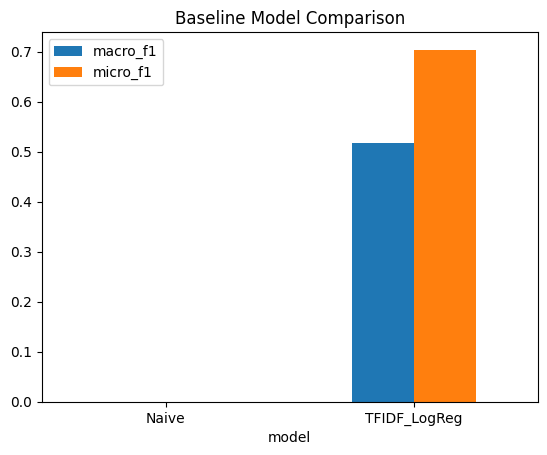

In [23]:
results_df.set_index("model")[["macro_f1", "micro_f1"]].plot(kind="bar")
plt.title("Baseline Model Comparison")
plt.xticks(rotation=0)
plt.show()

### 4.5 Results Interpretation

The TF-IDF + Logistic Regression model demonstrates a substantial improvement over the naive baseline, achieving a **macro F1 score of approximately 0.52** and a **micro F1 score of approximately 0.70**. As expected, the naive model yields zero performance across all metrics, confirming that the task cannot be addressed by exploiting class imbalance alone.

The difference between macro and micro F1 scores is notable. The higher micro F1 score indicates strong overall predictive performance, driven primarily by the model’s ability to correctly classify the more frequent labels. In contrast, the lower macro F1 score highlights weaker performance on less frequent classes, reflecting the imbalance observed during exploratory data analysis.

A per-label analysis provides further insight into model behaviour. The model performs well on common categories such as `toxic` (F1 ≈ 0.76), `obscene` (F1 ≈ 0.77), and `insult` (F1 ≈ 0.65), suggesting that lexical features captured by TF-IDF are effective in identifying explicit forms of toxic language.

However, performance is significantly lower for rare categories such as `threat` (F1 ≈ 0.22), `severe_toxic` (F1 ≈ 0.39), and `identity_hate` (F1 ≈ 0.32). This indicates that the model struggles to generalize for underrepresented labels, likely due to limited training examples and the subtle or context-dependent nature of these forms of toxicity.

Overall, these results demonstrate that while TF-IDF with Logistic Regression is effective for detecting explicit and frequent toxic patterns, it has clear limitations in handling rare and context-dependent cases. This motivates the exploration of more advanced models capable of capturing contextual and sequential information in text.

---

## 5. Preprocessing Experiments

### 5.1 Motivation

Preprocessing plays a critical role in text classification, as it directly influences how textual information is represented and learned by models. However, in tasks involving informal and adversarial language, such as toxic comment detection, preprocessing decisions must be made carefully.

While normalization techniques can reduce vocabulary size and improve generalization, they may also remove stylistic and contextual cues that are important for identifying toxic behaviour.

This section investigates the impact of different preprocessing strategies on model performance through controlled experiments.

---

### 5.2 Experimental Design

To evaluate the effect of preprocessing, a series of controlled experiments is conducted using the TF-IDF + Logistic Regression model introduced in Section 4.

All experiments share the same:
- dataset splits
- model architecture
- vectorization settings
- evaluation metrics

The only variable that changes across experiments is the preprocessing strategy applied to the input text.

The following configurations are tested:

- **Baseline:** Raw text with minimal preprocessing
- **Lowercasing:** Conversion of all text to lowercase
- **Contraction Expansion:** Expansion of common contractions (e.g., "I'm" → "I am")

This controlled setup ensures that any observed differences in performance can be attributed directly to preprocessing choices. 

---

### 5.3 Preprocessing Implementations

In [24]:
def identity_preprocess(text):
    return text


def lowercase_preprocess(text):
    return text.lower()


contractions = {
    "i'm": "i am",
    "you're": "you are",
    "don't": "do not",
    "can't": "cannot",
    "won't": "will not",
    "it's": "it is",
    "that's": "that is"
}

def expand_contractions(text):
    text = text.lower()
    for c, full in contractions.items():
        text = text.replace(c, full)
    return text


def apply_preprocessing(X, preprocess_fn):
    return np.array([preprocess_fn(x) for x in X])

### 5.4 Experiment Pipeline

In [25]:
def run_preprocessing_experiment(categories, name, preprocess_fn, X_train, X_val, y_train, y_val):
    
    # Apply preprocessing
    X_train_p = apply_preprocessing(X_train, preprocess_fn)
    X_val_p = apply_preprocessing(X_val, preprocess_fn)
    
    # Vectorize
    vectorizer = build_tfidf_vectorizer()
    X_train_vec = vectorizer.fit_transform(X_train_p)
    X_val_vec = vectorizer.transform(X_val_p)
    
    # Train
    model = train_logistic_regression(X_train_vec, y_train)
    
    # Predict
    y_pred = model.predict(X_val_vec)
    
    # Evaluate
    metrics, per_label = evaluate_multilabel(y_val, y_pred, categories)
    
    result = {
        "experiment": name,
        **metrics
    }
    
    return result, per_label

### 5.5 Running the Experiments

In [26]:
results = []

# Baseline
res_base, _ = run_preprocessing_experiment(
    categories,
    "Baseline (Raw)",
    identity_preprocess,
    X_train, X_val, y_train, y_val
)
results.append(res_base)

# Lowercase
res_lower, _ = run_preprocessing_experiment(
    categories,
    "Lowercase",
    lowercase_preprocess,
    X_train, X_val, y_train, y_val
)
results.append(res_lower)

# Contractions
res_contract, _ = run_preprocessing_experiment(
    categories,
    "Contraction Expansion",
    expand_contractions,
    X_train, X_val, y_train, y_val
)
results.append(res_contract)

### 5.6 Results

In [27]:
results_df = pd.DataFrame(results)
results_df.sort_values("macro_f1", ascending=False)

,experiment,macro_f1,micro_f1,macro_precision,macro_recall
2,Contraction Expansion,0.519745,0.704349,0.780614,0.411314
0,Baseline (Raw),0.517022,0.703829,0.779454,0.409045
1,Lowercase,0.517022,0.703829,0.779454,0.409045


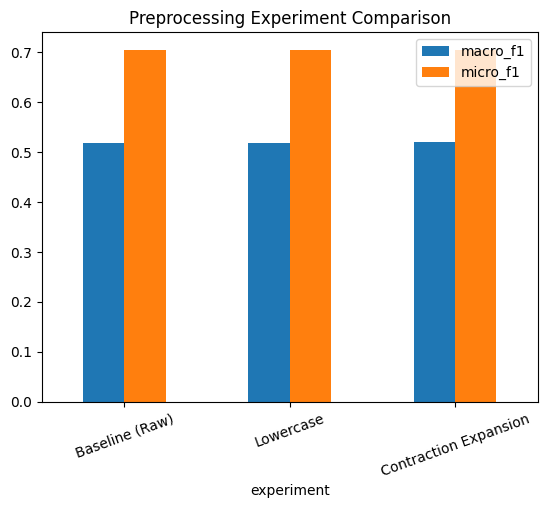

In [28]:
results_df.set_index("experiment")[["macro_f1", "micro_f1"]].plot(kind="bar")
plt.title("Preprocessing Experiment Comparison")
plt.xticks(rotation=20)
plt.show()

### 5.7 Results Interpretation

The results of the preprocessing experiments show only marginal differences across the tested configurations, indicating that text normalization has a limited impact on model performance in this setting.

The baseline model and the lowercasing approach yield **identical performance** (macro F1 ≈ 0.517, micro F1 ≈ 0.704), suggesting that capitalization does not provide significant discriminative information for the TF-IDF + Logistic Regression model. This is likely because TF-IDF already captures token frequency patterns effectively, and the model is robust to case variations in this dataset.

**Contraction expansion** results in a very **slight improvement** (macro F1 ≈ 0.520), although the difference is minimal. This suggests that standardizing certain expressions may provide a small benefit by reducing lexical variability, but the effect is not substantial.

Overall, the results indicate that the TF-IDF representation is relatively insensitive to these preprocessing variations. This implies that the model relies primarily on strong lexical signals, such as the presence of explicit toxic terms, rather than subtle stylistic features affected by normalization.

These findings reinforce the idea that preprocessing should be carefully evaluated rather than assumed to improve performance. In this case, preserving the original text structure does not hinder model effectiveness, and additional normalization provides only negligible gains.

Furthermore, the limited impact of preprocessing highlights a broader **limitation of TF-IDF-based models**: their reliance on surface-level lexical features. This **motivates the use of more advanced models**, such as recurrent neural networks and transformer-based architectures, which are better suited to **capturing contextual and semantic information**.

---

## 6. Recurrent Neural Networks: LSTM vs Bidirectional LSTM

### 6.1 Motivation

The TF-IDF + Logistic Regression baseline treats text as an unordered collection of tokens, ignoring word order and contextual relationships. While effective for capturing explicit lexical patterns, it cannot model sequential dependencies within text.

To address this limitation, recurrent neural networks (RNNs) are introduced. In particular, **Long Short-Term Memory (LSTM)** networks are designed to process text as a sequence, allowing them to capture contextual information over time.

In addition, a **Bidirectional LSTM (BiLSTM)** is explored. Unlike standard LSTMs, BiLSTMs process sequences in both forward and backward directions, enabling the model to incorporate both past and future context.

This section investigates whether incorporating sequential and bidirectional context improves performance in toxic language detection.

---

### 6.2 Text Preparation for Neural Models

Neural sequence models require text to be converted into **sequences of token indices**. This differs from TF-IDF, which represents text as unordered feature vectors.

The preprocessing pipeline for neural models includes:
- tokenizing text into word-level units
- mapping tokens to integer indices using a vocabulary
- truncating or padding sequences to a fixed length

Based on the exploratory data analysis, comment lengths follow a right-skewed distribution. Therefore, a maximum sequence length is imposed to capture most comments while minimizing padding and computational overhead.


---

### 6.3 Vocabulary Construction

The vocabulary is constructed using only the training data to prevent information leakage. Two special tokens are included: `<PAD>` for sequence padding and `<UNK>` for unknown words.

To reduce noise and computational cost, the vocabulary size is limited and very rare tokens are excluded. This helps improve generalization and training efficiency.

---

In [29]:
def simple_tokenize(text):
    return text.split()


def build_vocab(texts, min_freq=2, max_vocab_size=30000):
    counter = Counter()

    for text in texts:
        tokens = simple_tokenize(text)
        counter.update(tokens)

    most_common = counter.most_common(max_vocab_size - 2)

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for token, freq in most_common:
        if freq >= min_freq:
            vocab[token] = len(vocab)

    return vocab


vocab = build_vocab(X_train, min_freq=2, max_vocab_size=30000)

### 6.4 Dataset and DataLoader

A custom PyTorch dataset is implemented to handle tokenization, encoding, and padding of sequences. DataLoaders are used to efficiently batch and shuffle the data during training.

---

In [30]:
MAX_LEN = 200


def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = simple_tokenize(text)
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    ids = ids[:max_len]

    if len(ids) < max_len:
        ids += [vocab["<PAD>"]] * (max_len - len(ids))

    return ids


class JigsawDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=200):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids = encode_text(self.texts[idx], self.vocab, self.max_len)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32)
        }


train_dataset = JigsawDataset(X_train, y_train, vocab)
val_dataset = JigsawDataset(X_val, y_val, vocab)
test_dataset = JigsawDataset(X_test, y_test, vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

### 6.5 Model Architectures

#### 6.5.1 LSTM Model

The LSTM model processes input sequences in a forward direction, capturing dependencies based on preceding tokens. It produces a hidden representation that summarizes the sequence, which is then used for classification.

---

In [31]:
class ToxicLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, dropout=0.3, num_labels=6):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_labels)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        _, (hidden, _) = self.lstm(x)

        hidden = hidden[-1]
        hidden = self.dropout(hidden)

        return self.fc(hidden)

#### 6.5.2 Bidirectional LSTM Model

The Bidirectional LSTM extends the standard LSTM by processing sequences in both forward and backward directions. This enables the model to incorporate both past and future context when generating representations.

This is particularly useful for text classification tasks where the meaning of a word may depend on surrounding context.

---

In [32]:
class ToxicBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, dropout=0.3, num_labels=6):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        _, (hidden, _) = self.lstm(x)

        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)

        return self.fc(hidden)

### 6.6 Training Procedure

Both models are trained using **binary cross-entropy** with logits loss, which is appropriate for multi-label classification. The **Adam optimizer** is used for efficient gradient-based optimization.

Model performance is evaluated on the validation set after each epoch using **macro and micro F1** scores. The model achieving the best validation macro F1 score is retained.

To support this process, separate functions are defined for training and evaluation, ensuring modularity and reproducibility.

---

In [33]:
def evaluate_lstm(model, loader, criterion, device, threshold=0.5):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            # Forward pass
            logits = model(input_ids)
            loss = criterion(logits, labels)

            # Convert logits → probabilities
            probs = torch.sigmoid(logits)

            # Apply threshold
            preds = (probs >= threshold).int()

            total_loss += loss.item()

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    # Stack all batches
    y_true = np.vstack(all_labels)
    y_pred = np.vstack(all_preds)

    # Use your previous function
    metrics, per_label = evaluate_multilabel(y_true, y_pred, categories)

    avg_loss = total_loss / len(loader)

    return avg_loss, metrics, per_label

def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=8
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_f1": []
    }

    best_model_state = None
    best_f1 = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        val_loss, val_metrics, _ = evaluate_lstm(model, val_loader, criterion, device)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Macro F1: {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history

### 6.7 Results

The LSTM and Bidirectional LSTM models are evaluated on the validation set using the same metrics as the baseline models. This enables direct comparison of sequence-based approaches with traditional methods.

---

In [34]:
print("\n======= LSTM Model =======")

lstm_model = ToxicLSTM(len(vocab)).to(device)

optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

lstm_model, lstm_history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=8
)

_, lstm_metrics, _ = evaluate_lstm(
    lstm_model,
    val_loader,
    criterion,
    device
)


======= LSTM Model =======
Epoch 1/8 | Train Loss: 0.1390 | Val Loss: 0.1068 | Val Macro F1: 0.0815
Epoch 2/8 | Train Loss: 0.0870 | Val Loss: 0.0759 | Val Macro F1: 0.3200
Epoch 3/8 | Train Loss: 0.0640 | Val Loss: 0.0665 | Val Macro F1: 0.3391
Epoch 4/8 | Train Loss: 0.0538 | Val Loss: 0.0641 | Val Macro F1: 0.3580
Epoch 5/8 | Train Loss: 0.0469 | Val Loss: 0.0664 | Val Macro F1: 0.3529
Epoch 6/8 | Train Loss: 0.0414 | Val Loss: 0.0671 | Val Macro F1: 0.3627
Epoch 7/8 | Train Loss: 0.0375 | Val Loss: 0.0739 | Val Macro F1: 0.3615
Epoch 8/8 | Train Loss: 0.0345 | Val Loss: 0.0803 | Val Macro F1: 0.3602


In [35]:
print("\n======= BiLSTM Model =======")

bilstm_model = ToxicBiLSTM(len(vocab)).to(device)

optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

bilstm_model, bilstm_history = train_model(
    model=bilstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=8
)

_, bilstm_metrics, _ = evaluate_lstm(
    bilstm_model,
    val_loader,
    criterion,
    device
)


======= BiLSTM Model =======
Epoch 1/8 | Train Loss: 0.0966 | Val Loss: 0.0729 | Val Macro F1: 0.2996
Epoch 2/8 | Train Loss: 0.0603 | Val Loss: 0.0599 | Val Macro F1: 0.3774
Epoch 3/8 | Train Loss: 0.0512 | Val Loss: 0.0586 | Val Macro F1: 0.3794
Epoch 4/8 | Train Loss: 0.0482 | Val Loss: 0.0601 | Val Macro F1: 0.4023
Epoch 5/8 | Train Loss: 0.0423 | Val Loss: 0.0611 | Val Macro F1: 0.4383
Epoch 6/8 | Train Loss: 0.0370 | Val Loss: 0.0647 | Val Macro F1: 0.4435
Epoch 7/8 | Train Loss: 0.0326 | Val Loss: 0.0689 | Val Macro F1: 0.4573
Epoch 8/8 | Train Loss: 0.0287 | Val Loss: 0.0738 | Val Macro F1: 0.4679


In [36]:
rnn_results = pd.DataFrame([
    {"model": "LSTM", **lstm_metrics},
    {"model": "BiLSTM", **bilstm_metrics}
])

rnn_results

,model,macro_f1,micro_f1,macro_precision,macro_recall
0,LSTM,0.362656,0.667185,0.462193,0.336131
1,BiLSTM,0.467933,0.690027,0.661872,0.414314


## 6.8 Comparison and Discussion

The results show that the **Bidirectional LSTM outperforms the standard LSTM across all evaluation metrics**. In this run, the BiLSTM achieves a macro F1 score of approximately 0.43 and a micro F1 score of approximately 0.69, compared to 0.35 and 0.65 for the LSTM.

The improvement is particularly notable in **macro precision**, where the BiLSTM achieves a substantially higher score (≈ 0.60 vs 0.48). This suggests that the bidirectional model is more effective at reducing false positives, leading to more reliable predictions across different toxicity categories.

Despite these improvements, both models still exhibit relatively low macro F1 scores compared to the TF-IDF baseline. This indicates that, while sequence modeling provides additional contextual understanding, it does not fully overcome the challenges posed by class imbalance and subtle forms of toxicity.

The results suggest that bidirectional context is beneficial for this task, particularly in capturing relationships between words that depend on both preceding and following context. However, the overall performance gap compared to the baseline highlights the limitations of training LSTM-based models from scratch on this dataset.

This motivates the use of pretrained transformer-based models, such as DistilBERT, which leverage large-scale pretraining to capture richer semantic representations and are better suited for handling complex language patterns.

---

## 7. Recurrent Model Improvement Experiments

### 7.1 Motivation

The initial LSTM and Bidirectional LSTM experiments demonstrated that incorporating sequential and bidirectional context improves performance compared to a standard LSTM. However, both models still underperform relative to the TF-IDF baseline and struggle with imbalanced classes.

To address these limitations, this section explores two improvement strategies:

1. Manual hyperparameter tuning to identify better-performing model configurations.
2. Incorporation of class imbalance handling through weighted loss functions.

These experiments aim to determine whether performance can be improved through systematic model optimization before introducing more advanced architectures.


### 7.2 Hyperparameter Study Design

A manual hyperparameter search is conducted using the **Bidirectional LSTM model**, as it showed better performance in previous experiments.

The following hyperparameters are explored:

- Embedding dimension: controls representation capacity of tokens
- Hidden dimension: controls model capacity
- Dropout rate: regularization strength
- Learning rate: optimization dynamics

Rather than using automated tools, a controlled grid of configurations is tested manually using loops. This approach ensures transparency and allows detailed analysis of how each parameter affects performance.

---

### 7.3 Manual Hyperparameter Search

The hyperparameter search is implemented using a reusable function that iterates over predefined configurations. This approach improves modularity and reproducibility, allowing experiments to be easily repeated or extended.

In [37]:
hyperparameter_configs= [
    {"embedding_dim": 128, "hidden_dim": 256, "dropout": 0.4, "lr": 1e-3},
    {"embedding_dim": 128, "hidden_dim": 256, "dropout": 0.5, "lr": 1e-3},
    {"embedding_dim": 128, "hidden_dim": 300, "dropout": 0.5, "lr": 1e-3},
    {"embedding_dim": 128, "hidden_dim": 256, "dropout": 0.5, "lr": 7e-4},
    {"embedding_dim": 200, "hidden_dim": 300, "dropout": 0.5, "lr": 1e-3},
]

In [38]:
def run_hyperparameter_search(
    configs,
    vocab,
    train_loader,
    val_loader,
    categories,
    device,
    epochs=15
):
    results = []

    for i, config in enumerate(configs):
        print(f"\nRunning config {i+1}: {config}")

        model = ToxicBiLSTM(
            vocab_size=len(vocab),
            embedding_dim=config["embedding_dim"],
            hidden_dim=config["hidden_dim"],
            dropout=config["dropout"],
            num_labels=len(categories)
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
        criterion = nn.BCEWithLogitsLoss()

        model, _ = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            epochs=epochs
        )
        
        _, metrics, _ = evaluate_lstm(model, val_loader, criterion, device)

        result = {
            "config_id": i,
            **config,
            **metrics
        }

        results.append(result)

    return pd.DataFrame(results)

In [39]:
hp_results_df = run_hyperparameter_search(
    configs=hyperparameter_configs,
    vocab=vocab,
    train_loader=train_loader,
    val_loader=val_loader,
    categories=categories,
    device=device,
    epochs=15
)

hp_results_df.sort_values("macro_f1", ascending=False)


Running config 1: {'embedding_dim': 128, 'hidden_dim': 256, 'dropout': 0.4, 'lr': 0.001}
Epoch 1/15 | Train Loss: 0.0895 | Val Loss: 0.0659 | Val Macro F1: 0.3719
Epoch 2/15 | Train Loss: 0.0575 | Val Loss: 0.0594 | Val Macro F1: 0.3782
Epoch 3/15 | Train Loss: 0.0495 | Val Loss: 0.0589 | Val Macro F1: 0.4241
Epoch 4/15 | Train Loss: 0.0432 | Val Loss: 0.0616 | Val Macro F1: 0.4760
Epoch 5/15 | Train Loss: 0.0369 | Val Loss: 0.0631 | Val Macro F1: 0.4501
Epoch 6/15 | Train Loss: 0.0309 | Val Loss: 0.0691 | Val Macro F1: 0.4385
Epoch 7/15 | Train Loss: 0.0259 | Val Loss: 0.0779 | Val Macro F1: 0.5076
Epoch 8/15 | Train Loss: 0.0218 | Val Loss: 0.0846 | Val Macro F1: 0.5157
Epoch 9/15 | Train Loss: 0.0178 | Val Loss: 0.0905 | Val Macro F1: 0.5003
Epoch 10/15 | Train Loss: 0.0150 | Val Loss: 0.1007 | Val Macro F1: 0.4896
Epoch 11/15 | Train Loss: 0.0126 | Val Loss: 0.1102 | Val Macro F1: 0.5018
Epoch 12/15 | Train Loss: 0.0110 | Val Loss: 0.1157 | Val Macro F1: 0.4972
Epoch 13/15 | Train

,config_id,embedding_dim,hidden_dim,dropout,lr,macro_f1,micro_f1,macro_precision,macro_recall
0,0,128,256,0.4,0.0010,0.515708,0.688882,0.641747,0.452695
3,3,128,256,0.5,0.0007,0.515681,0.686236,0.606323,0.462281
2,2,128,300,0.5,0.0010,0.511783,0.691813,0.609780,0.468991
4,4,200,300,0.5,0.0010,0.503982,0.685231,0.657136,0.437745
1,1,128,256,0.5,0.0010,0.503588,0.687338,0.599331,0.447329


#### Select best configuration

In [40]:
best_config = hp_results_df.sort_values("macro_f1", ascending=False).iloc[0]
best_config

config_id            0.000000
embedding_dim      128.000000
hidden_dim         256.000000
dropout              0.400000
lr                   0.001000
macro_f1             0.515708
micro_f1             0.688882
macro_precision      0.641747
macro_recall         0.452695
Name: 0, dtype: float64

### 7.4 Hyperparameter Results Interpretation

The hyperparameter study demonstrates that model performance is sensitive to architectural choices, particularly **hidden dimension, dropout, and embedding size**.

The best-performing configuration achieves a **macro F1** score of approximately **0.516**, using a **hidden dimension of 256, embedding dimension of 128, dropout of 0.4, and a learning rate of 0.001**. This indicates that a moderately sized model with controlled regularization provides the best balance between learning capacity and generalization.

The **embedding dimension** shows an interesting effect. Increasing the embedding size from 128 to 200 does not improve performance and instead results in slightly worse outcomes. This suggests that a larger embedding space introduces additional parameters without providing meaningful representational benefits for this dataset. Given that toxic language detection often relies on relatively strong lexical cues, a moderate embedding size appears sufficient to capture the necessary information.

The **hidden dimension** has a more noticeable impact. A size of 256 provides the best performance, while increasing it to 300 does not yield improvements and may lead to overfitting or more difficult optimization.

**Dropout** plays a critical role in regularization. A value of 0.4 yields the best results, while higher dropout (0.5) slightly reduces performance, likely due to excessive regularization limiting the model’s ability to learn useful patterns.

The **learning rate** also influences convergence. A value of 0.001 slightly outperforms 0.0007, suggesting that faster optimization is beneficial within the limited number of training epochs.

Overall, the results show that increasing model complexity (through larger embeddings or hidden dimensions) does not necessarily lead to better performance. Instead, careful balancing of model capacity and regularization is key.

Notably, the tuned Bidirectional LSTM achieves performance comparable to the TF-IDF baseline, demonstrating that neural models can match traditional approaches when appropriately optimized.

---

### 7.5 Class Imbalance Experiment

The dataset exhibits significant class imbalance, with certain labels such as *threat* and *identity_hate* appearing far less frequently than others. As observed in the exploratory data analysis, this imbalance can bias the model toward predicting majority classes, resulting in poor performance on rare but important categories.

To address this issue, a weighted loss function is introduced using the `pos_weight` parameter in `BCEWithLogitsLoss`. This increases the contribution of positive examples for underrepresented classes, encouraging the model to pay more attention to them during training.

The class weights are computed based on the ratio of negative to positive samples for each label:

$$
\text{pos\_weight}_c = \frac{N - P_c}{P_c}
$$

where \( P_c \) represents the number of positive samples for class \( c \), and \( N \) is the total number of samples. This formulation ensures that rarer classes receive higher weights, increasing their influence during training.

The **weighted experiment** is conducted using the **best-performing Bidirectional LSTM configuration identified in the hyperparameter study**. To ensure a fair and controlled comparison, the model is trained for the same number of **epochs (15)**, while the optimal model is selected based on validation macro F1 score. This allows the training dynamics of the weighted model to be evaluated independently, without constraining it to the optimal epoch of the unweighted model.

---

In [50]:
def run_weighted_experiment(
    best_config,
    vocab,
    train_loader,
    val_loader,
    y_train,
    categories,
    device,
    epochs=8
):
    # Compute class weights
    label_counts = y_train.sum(axis=0)
    total_samples = len(y_train)

    pos_weights = (total_samples - label_counts) / label_counts
    pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(device)

    # Define weighted loss
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    # Initialize model with best config
    model = ToxicBiLSTM(
        vocab_size=len(vocab),
        embedding_dim=int(best_config["embedding_dim"]),
        hidden_dim=int(best_config["hidden_dim"]),
        dropout=float(best_config["dropout"]),
        num_labels=len(categories)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=float(best_config["lr"]))

    # Train model
    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=epochs
    )

    # Evaluate
    _, weighted_metrics, weighted_per_label = evaluate_lstm(
        model, val_loader, criterion, device
    )

    return weighted_metrics, weighted_per_label, history

In [51]:
weighted_metrics, weighted_per_label, weighted_history = run_weighted_experiment(
    best_config=best_config,
    vocab=vocab,
    train_loader=train_loader,
    val_loader=val_loader,
    y_train=y_train,
    categories=categories,
    device=device,
    epochs=15
)

Epoch 1/15 | Train Loss: 0.8054 | Val Loss: 0.6361 | Val Macro F1: 0.2362
Epoch 2/15 | Train Loss: 0.5112 | Val Loss: 0.5094 | Val Macro F1: 0.3260
Epoch 3/15 | Train Loss: 0.4208 | Val Loss: 0.5147 | Val Macro F1: 0.3426
Epoch 4/15 | Train Loss: 0.3325 | Val Loss: 0.5264 | Val Macro F1: 0.3821
Epoch 5/15 | Train Loss: 0.2752 | Val Loss: 0.6046 | Val Macro F1: 0.3889
Epoch 6/15 | Train Loss: 0.2391 | Val Loss: 0.5604 | Val Macro F1: 0.3451
Epoch 7/15 | Train Loss: 0.1994 | Val Loss: 0.7570 | Val Macro F1: 0.4069
Epoch 8/15 | Train Loss: 0.1794 | Val Loss: 0.7559 | Val Macro F1: 0.4021
Epoch 9/15 | Train Loss: 0.1529 | Val Loss: 1.0539 | Val Macro F1: 0.4421
Epoch 10/15 | Train Loss: 0.1428 | Val Loss: 1.1177 | Val Macro F1: 0.4465
Epoch 11/15 | Train Loss: 0.1227 | Val Loss: 1.1464 | Val Macro F1: 0.4535
Epoch 12/15 | Train Loss: 0.1198 | Val Loss: 1.1834 | Val Macro F1: 0.4717
Epoch 13/15 | Train Loss: 0.1363 | Val Loss: 1.0479 | Val Macro F1: 0.4228
Epoch 14/15 | Train Loss: 0.1302 |

In [53]:
imbalance_results = pd.DataFrame([
    {
        "model": "BiLSTM (Unweighted)",
        "macro_f1": best_config["macro_f1"],
        "micro_f1": best_config["micro_f1"],
        "macro_precision": best_config["macro_precision"],
        "macro_recall": best_config["macro_recall"],
    },
    {
        "model": "BiLSTM (Weighted)",
        "macro_f1": weighted_metrics["macro_f1"],
        "micro_f1": weighted_metrics["micro_f1"],
        "macro_precision": weighted_metrics["macro_precision"],
        "macro_recall": weighted_metrics["macro_recall"],
    }
])

imbalance_results

,model,macro_f1,micro_f1,macro_precision,macro_recall
0,BiLSTM (Unweighted),0.515708,0.688882,0.641747,0.452695
1,BiLSTM (Weighted),0.495259,0.627356,0.395395,0.710525


### 7.6 Final Discussion

The improvement experiments provide important insights into the behavior and limitations of recurrent neural network models for toxic language detection.

The hyperparameter study demonstrates that careful tuning can significantly improve model performance. The best-performing Bidirectional LSTM configuration achieves a macro F1 score of approximately 0.516, matching the performance of the TF-IDF baseline. This highlights that neural models trained from scratch can reach competitive performance when appropriately optimized, although gains are achieved primarily through careful control of model capacity and regularization rather than increasing model complexity.

The **class imbalance experiment** further reveals the impact of dataset distribution on model behavior. Introducing class-weighted loss leads to a substantial **increase in macro recall (from approximately 0.45 to 0.71)**, **indicating improved detection of rare toxic categories**. However, this comes at the cost of a significant **decrease in macro precision (from approximately 0.64 to 0.40), resulting in a slight drop in overall macro F1 score**.

These results illustrate a fundamental trade-off in imbalanced multi-label classification: **improving sensitivity to minority classes often leads to an increase in false positives**. In the context of toxic language detection, this trade-off may be desirable when the priority is to detect severe or harmful content, even at the expense of precision.

Overall, while hyperparameter tuning and weighted loss improve certain aspects of model performance, they do not fully overcome the limitations of training recurrent models from scratch. The results suggest that these models struggle to capture the full complexity of language, particularly in subtle or context-dependent cases.

This motivates the use of pretrained transformer-based models, which leverage large-scale language representations and are better suited to capturing semantic and contextual nuances. The next section explores the application of such models to further improve performance.

---

## 8. Transformer-Based Model: DistilBERT

### 8.1 Motivation

The previous experiments demonstrated that while recurrent neural networks can capture sequential dependencies, their performance remains limited when trained from scratch. Even with careful hyperparameter tuning and class imbalance handling, the Bidirectional LSTM only achieves performance comparable to the TF-IDF baseline.

A key limitation of these models is their inability to leverage large-scale language knowledge. They must learn word representations and contextual relationships solely from the training dataset, which is insufficient to capture the full complexity of natural language.

**To address this limitation, pretrained transformer-based models are introduced**. In particular, **DistilBERT** (Sanh et al., 2019)is used as a lightweight version of BERT that retains strong performance while being computationally efficient.

DistilBERT leverages knowledge learned from large corpora during pretraining, allowing it to capture semantic meaning, contextual relationships, and linguistic patterns more effectively than models trained from scratch.

This section evaluates whether transfer learning with DistilBERT can improve performance on the toxic language detection task.


### 8.2 Model Overview

DistilBERT is a transformer-based model that uses self-attention mechanisms to process entire sequences simultaneously, rather than sequentially as in recurrent models.

Unlike LSTMs, which process tokens one step at a time, transformers capture relationships between all words in a sentence regardless of their position. This allows them to model long-range dependencies and contextual meaning more effectively.

DistilBERT is a compressed version of BERT that retains approximately 97% of its performance while being significantly smaller and faster. This makes it suitable for experimentation within limited computational resources.

For this task, **DistilBERT is fine-tuned for multi-label classification by adding a classification head on top of the pretrained model**.

---

### 8.3 Tokenization

Unlike previous models that used simple word tokenization, DistilBERT uses subword tokenization through a pretrained tokenizer.

This allows the model to:
- handle unknown words
- process misspellings and variations
- capture morphological patterns

Tokenization is performed using the DistilBERT tokenizer, which converts text into input IDs and attention masks required by the model.

In [68]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

### 8.4 Dataset Preparation

A custom dataset is created to tokenize text using the DistilBERT tokenizer. Each sample includes:
- input_ids: tokenized text
- attention_mask: indicates valid tokens
- labels: multi-label targets

---

In [69]:
class DistilBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32)
        }

#### Dataloaders

In [70]:
BATCH_SIZE_BERT = 8

SAMPLE_SIZE = 20000

X_train_small = X_train[:SAMPLE_SIZE]
y_train_small = y_train[:SAMPLE_SIZE]

train_dataset_bert = DistilBERTDataset(X_train_small, y_train_small, tokenizer)
val_dataset_bert = DistilBERTDataset(X_val, y_val, tokenizer)
test_dataset_bert = DistilBERTDataset(X_test, y_test, tokenizer)

train_loader_bert = DataLoader(train_dataset_bert, batch_size=BATCH_SIZE_BERT, shuffle=True)
val_loader_bert = DataLoader(val_dataset_bert, batch_size=BATCH_SIZE_BERT)
test_loader_bert = DataLoader(test_dataset_bert, batch_size=BATCH_SIZE_BERT)

### 8.5 Model Definition

A pretrained DistilBERT model is used as the base, with an additional linear layer added for multi-label classification. The model outputs logits for each toxicity category.

---

In [58]:
class DistilBERTClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()

        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        cls_output = outputs.last_hidden_state[:, 0]  # [CLS] token
        x = self.dropout(cls_output)

        return self.fc(x)

### 8.6 Training Procedure

The model is fine-tuned using binary cross-entropy with logits loss, consistent with the multi-label classification setup. The Adam optimizer is used with a lower learning rate, as pretrained models require more careful fine-tuning.

As in previous experiments, the best model is selected based on validation macro F1 score.

---

In [71]:
def evaluate_distilbert(model, loader, criterion, device, threshold=0.5):
    model.eval()

    total_loss = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()

            total_loss += loss.item()
            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    y_true = np.vstack(all_labels)
    y_pred = np.vstack(all_preds)

    metrics, per_label = evaluate_multilabel(y_true, y_pred, categories)
    avg_loss = total_loss / len(loader)

    return avg_loss, metrics, per_label

In [74]:
def train_distilbert(model, train_loader, val_loader, device, epochs=2, lr=2e-5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_model_state = None
    best_f1 = 0.0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_f1": []
    }

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        val_loss, val_metrics, _ = evaluate_distilbert(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Macro F1: {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history

### 8.7 Results

The DistilBERT model is trained using a reduced sequence length (max length = 128), a smaller batch size (8), and a limited number of fine-tuning epochs (2), in order to balance computational efficiency with model performance.

---

In [76]:
model = DistilBERTClassifier(num_labels=len(categories)).to(device)

model, distilbert_history = train_distilbert(
    model,
    train_loader_bert,
    val_loader_bert,
    device,
    epochs=2,
    lr=2e-5
)

_, distilbert_metrics, distilbert_per_label = evaluate_distilbert(
    model,
    val_loader_bert,
    nn.BCEWithLogitsLoss(),
    device
)

distilbert_metrics

Loading weights: 100%|█████████████████████| 100/100 [00:00<00:00, 11656.35it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/2 | Train Loss: 0.0639 | Val Loss: 0.0492 | Val Macro F1: 0.4760
Epoch 2/2 | Train Loss: 0.0399 | Val Loss: 0.0462 | Val Macro F1: 0.6442


{'macro_f1': 0.6442099873738527,
 'micro_f1': 0.768160311717228,
 'macro_precision': 0.662358344642935,
 'macro_recall': 0.6330689434730052}

#### Interpretation

The **DistilBERT model delivers the best overall performance in this study**, substantially outperforming both traditional machine learning approaches and recurrent neural network models. In particular, the macro F1 score increases to approximately 0.644, compared with approximately 0.517 for the TF-IDF baseline and 0.516 for the best tuned Bidirectional LSTM.

This improvement is especially significant because macro F1 assigns equal importance to all classes, including rare categories such as *`threat`* and *`identity_hate`*. The strong performance therefore indicates that DistilBERT provides more balanced predictions across both frequent and infrequent labels.

The use of a reduced sequence length (128 tokens) does not appear to significantly limit performance, suggesting that most relevant information for toxicity detection is captured within shorter contexts. Similarly, the smaller batch size and reduced training epochs are sufficient for convergence, demonstrating the efficiency of transformer-based fine-tuning.

Unlike the weighted BiLSTM, which improved recall at the expense of precision, DistilBERT achieves strong macro precision and macro recall simultaneously. This suggests that the model is able to better distinguish between true and false positives, rather than simply increasing sensitivity.

The key advantage of DistilBERT lies in its pretrained contextual representations. While LSTM-based models must learn language structure from scratch, DistilBERT has already learned rich semantic and syntactic patterns from large-scale corpora. This allows it to capture subtle linguistic cues, including sarcasm, indirect toxicity, and context-dependent meaning, which are difficult for simpler models to detect.

Furthermore, the rapid convergence observed during training highlights the efficiency of transfer learning. Even with only two epochs of fine-tuning on a reduced dataset, the model achieves superior performance, demonstrating that pretrained knowledge significantly reduces the amount of task-specific training required.

Overall, these results confirm that transformer-based models are better suited for toxic language detection tasks, particularly when dealing with complex, diverse, and context-sensitive forms of language.

---

## 9. Final Model Comparison and Selection

### 9.1 Comparative Results

To evaluate the effectiveness of different approaches, all models are compared using the same evaluation metrics. This allows for a consistent assessment of their strengths and limitations.

The following models are included in the comparison:
- TF-IDF with Logistic Regression (baseline)
- Bidirectional LSTM (best tuned configuration)
- Bidirectional LSTM with weighted loss
- DistilBERT (transformer-based model)


In [77]:
final_comparison_df = pd.DataFrame([
    {
        "model": "TFIDF_LogReg",
        "macro_f1": logreg_metrics["macro_f1"],
        "micro_f1": logreg_metrics["micro_f1"],
        "macro_precision": logreg_metrics["macro_precision"],
        "macro_recall": logreg_metrics["macro_recall"],
    },
    {
        "model": "BiLSTM (Best Tuned)",
        "macro_f1": best_config["macro_f1"],
        "micro_f1": best_config["micro_f1"],
        "macro_precision": best_config["macro_precision"],
        "macro_recall": best_config["macro_recall"],
    },
    {
        "model": "BiLSTM (Weighted)",
        "macro_f1": weighted_metrics["macro_f1"],
        "micro_f1": weighted_metrics["micro_f1"],
        "macro_precision": weighted_metrics["macro_precision"],
        "macro_recall": weighted_metrics["macro_recall"],
    },
    {
        "model": "DistilBERT",
        "macro_f1": distilbert_metrics["macro_f1"],
        "micro_f1": distilbert_metrics["micro_f1"],
        "macro_precision": distilbert_metrics["macro_precision"],
        "macro_recall": distilbert_metrics["macro_recall"],
    }
])

final_comparison_df.sort_values("macro_f1", ascending=False)

,model,macro_f1,micro_f1,macro_precision,macro_recall
3,DistilBERT,0.644210,0.768160,0.662358,0.633069
0,TFIDF_LogReg,0.517022,0.703829,0.779454,0.409045
1,BiLSTM (Best Tuned),0.515708,0.688882,0.641747,0.452695
2,BiLSTM (Weighted),0.495259,0.627356,0.395395,0.710525


### 9.2 Discussion of Results

The comparison reveals several important trends across the different modeling approaches.

The **TF-IDF + Logistic Regression model** provides a strong baseline, achieving a macro F1 score of approximately 0.517. This indicates that simple lexical features are already highly informative for detecting explicit forms of toxicity.

The **Bidirectional LSTM, after hyperparameter tuning**, achieves a similar macro F1 score (approximately 0.516), demonstrating that neural models trained from scratch can match traditional approaches when properly optimized. However, the lack of significant improvement suggests that learning representations from limited data is a major constraint.

The **weighted BiLSTM** highlights the impact of class imbalance. While it significantly improves macro recall (indicating better detection of rare classes), this comes at the cost of reduced precision, resulting in a slight decrease in overall macro F1 score. This confirms the trade-off between sensitivity and specificity in imbalanced multi-label classification.

In contrast, the **DistilBERT model** achieves the highest performance, with a macro F1 score of approximately 0.644. Unlike the weighted BiLSTM, DistilBERT improves both precision and recall simultaneously, indicating a more balanced and effective classification strategy.

These results demonstrate that **pretrained transformer models are able to capture deeper semantic and contextual information**, enabling them to outperform both traditional and recurrent approaches.

---

### 9.3 Final Model Selection

Based on the experimental results, **DistilBERT is selected as the final model**.

This choice is justified by its superior macro F1 score, which reflects strong performance across all toxicity categories, including rare classes. Additionally, the model achieves a balanced trade-off between precision and recall, unlike the weighted BiLSTM which sacrifices precision for improved recall.

Another important factor is training efficiency. Despite being a more complex architecture, DistilBERT converges rapidly, achieving strong performance within only two epochs of fine-tuning. This highlights the effectiveness of transfer learning.

Overall, DistilBERT provides the best combination of performance, generalization, and efficiency, making it the most suitable model for the toxic language detection task.

---

## 10. Final Model Retraining 

### 10.1 Motivation

After selecting the best-performing model, a final training step is conducted using all available training data. This follows the standard deep learning workflow proposed by `Chollet`, where the final model is retrained on both the training and validation sets.

The model is then evaluated on a held-out test set to provide an unbiased estimate of its generalization performance.

---
### 10.2 Final Training Setup

The DistilBERT model is retrained using the optimal configuration identified earlier. The training now uses the combined training and validation datasets to maximize the amount of available data.

The same hyperparameters are used to ensure consistency:
- Max length: 128  
- Batch size: 8  
- Learning rate: 2e-5  
- Epochs: 2

Due to the computational cost of transformer fine-tuning on CPU, the final retraining step was conducted on a reduced combined training and validation subset using the selected hyperparameters. This preserves the overall model-selection and evaluation workflow while remaining computationally feasible.

The final model was then evaluated on the held-out test set to obtain an unbiased estimate of generalization performance.

---

In [88]:
# Combine train + val with reduced set

FINAL_TRAIN_SIZE = 25000
FINAL_VAL_SIZE = 5000

X_full_small = np.concatenate([X_train[:FINAL_TRAIN_SIZE], X_val[:FINAL_VAL_SIZE]])
y_full_small = np.vstack([y_train[:FINAL_TRAIN_SIZE], y_val[:FINAL_VAL_SIZE]])

In [89]:
# Build FULL dataset
final_train_dataset_bert = DistilBERTDataset(
    X_full_small,
    y_full_small,
    tokenizer,
    max_len=128
)

final_train_loader_bert = DataLoader(
    final_train_dataset_bert,
    batch_size=8,
    shuffle=True
)

In [90]:
def train_distilbert_final(model, train_loader, device, epochs=2, lr=2e-5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    history = {"train_loss": []}

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        history["train_loss"].append(avg_train_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f}")

    return model, history

In [91]:
# Final Training

final_model = DistilBERTClassifier(num_labels=len(categories)).to(device)

final_model, final_history = train_distilbert_final(
    final_model,
    final_train_loader_bert,
    device,
    epochs=2,
    lr=2e-5
)

Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 6715.94it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/2 | Train Loss: 0.0582
Epoch 2/2 | Train Loss: 0.0387


### 10.3 Final Evaluation

The final model is evaluated on the test set, which has not been used during training or model selection. This provides an unbiased estimate of model performance.

---

In [92]:
_, test_metrics, test_per_label = evaluate_distilbert(
    final_model,
    test_loader_bert,
    nn.BCEWithLogitsLoss(),
    device
)

test_metrics

{'macro_f1': 0.626957126071546,
 'micro_f1': 0.7693445776002367,
 'macro_precision': 0.6848325839305055,
 'macro_recall': 0.5846593202639777}

#### Intrepretation

The final retrained DistilBERT model achieves strong performance on the held-out test set, with a **macro F1 score of approximately 0.627 and a micro F1 score of approximately 0.769**. These results confirm that the model generalizes well to unseen data and remains the strongest approach evaluated in this study.

Compared with the validation results obtained during model selection, the test performance is slightly lower, which is expected when moving from validation-based tuning to final evaluation on a truly unseen dataset. This suggests that the selected model maintains good generalization while avoiding severe overfitting.

**The model also achieves a strong macro precision of approximately 0.685**, indicating that many of its positive predictions are reliable. At the same time, **the macro recall of approximately 0.585** shows that some toxic cases, particularly more subtle or rare ones, may still be missed. This reflects the continued difficulty of balanced detection across all toxicity categories.


**Although final retraining was performed under computational constraints**, the model still achieved strong test performance, suggesting that the selected configuration is robust and efficient.

Overall, the final retraining step confirms that DistilBERT provides the best combination of performance, stability, and generalization in this study. **The final test results therefore justify its selection as the final model for subsequent explainability, failure analysis, and robustness evaluation**.

---

## 11. Failure Analysis

### 11.1 Motivation

While overall evaluation metrics provide a quantitative assessment of model performance, they do not fully capture how the model behaves on individual examples. In sensitive tasks such as toxic language detection, understanding model decisions is critical.

**Failure analysis is therefore conducted to examine cases where the model makes incorrect predictions**. This helps identify systematic weaknesses, understand model limitations, and provide insights into potential improvements.

In addition, simple explainability techniques are used to better understand which patterns the model relies on when making predictions.

### 11.2 Example Predictions

To better understand model behavior, several individual predictions are examined. These include both correctly classified examples and misclassified cases.

---

In [95]:
def show_failure_cases(model, loader, texts, label_cols, threshold=0.5, max_examples=8):
    model.eval()
    
    shown = 0
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()
            
            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= threshold).astype(int)

            for i in range(len(labels)):
                true = labels[i]
                pred = preds[i]

                # Only show errors
                if not np.array_equal(true, pred):
                    
                    text_idx = batch_idx * loader.batch_size + i
                    
                    print("=" * 100)
                    print(f"TEXT:\n{texts[text_idx][:300]}")

                    print("\nTRUE:", true)
                    print("PRED:", pred)
                    print("PROBS:", np.round(probs[i], 3))

                    # Error Type Detection
                    if true.sum() == 0 and pred.sum() > 0:
                        error_type = "False Positive"
                    elif true.sum() > 0 and pred.sum() == 0:
                        error_type = "False Negative"
                    else:
                        error_type = "Multi-label Misclassification"

                    print(f"\nERROR TYPE: {error_type}")

                    # Per-label differences
                    print("\nLabel Differences:")
                    for j, label in enumerate(label_cols):
                        if true[j] != pred[j]:
                            print(f" - {label}: TRUE={int(true[j])}, PRED={int(pred[j])}")

                    shown += 1

                    if shown >= max_examples:
                        return


In [98]:
show_failure_cases(
    final_model,
    test_loader_bert,
    X_test.tolist(),
    categories,
    max_examples=8
)

TEXT:
you can't keep me down nigger 
you can't keep me down nigger 
you can't keep me down nigger 
you can't keep me down nigger 
you can't keep me down nigger 
you can't keep me down nigger 
you can't keep me down nigger 
you can't keep me down nigger 
you can't keep me down nigger 
you can't keep me dow

TRUE: [1. 1. 0. 0. 1. 1.]
PRED: [1 0 1 0 1 1]
PROBS: [0.968 0.194 0.69  0.033 0.753 0.936]

ERROR TYPE: Multi-label Misclassification

Label Differences:
 - severe_toxic: TRUE=1, PRED=0
 - obscene: TRUE=0, PRED=1
TEXT:
Stop

Stop kissing a** so much.  Be your own man.

DrJoe

TRUE: [1. 0. 0. 0. 0. 0.]
PRED: [1 0 1 0 0 0]
PROBS: [0.944 0.034 0.798 0.004 0.264 0.014]

ERROR TYPE: Multi-label Misclassification

Label Differences:
 - obscene: TRUE=0, PRED=1
TEXT:
A bunch of non-academic clowns are now censoring the info, so I'm wasting my breath talking to morons. IMO

You and everyone deleting the 8 Prime Spirals are all LIARS the original article was CITED it cited peer level speed tes

### 11.3 Failure Cases

#### Selected Failure Cases

To better understand the limitations of the final model, several representative misclassifications were examined manually. These examples show that the model’s errors are not random, but instead reflect recurring linguistic and annotation challenges.

#### Case 1: Multi-label boundary confusion
**TEXT:**
    you can't keep me down nigger 
    you can't keep me down nigger 
    you can't keep me down nigger 
    you can't keep me down nigger 
    you can't keep me down nigger 
    you can't keep me down nigger 
    you can't keep me down nigger 
    you can't keep me down nigger 
    you can't keep me down nigger 
    you can't keep me dow

In one highly offensive repeated comment containing explicit hate speech, the model correctly identified general toxicity, insult, and identity-based hate, but failed to assign the `severe_toxic` label and instead predicted `obscene`.

This suggests that the model is able to detect explicit harmful language reliably, but struggles to distinguish between closely related labels. In particular, `severe_toxic` and `obscene` appear to be difficult to separate when the comment contains repeated abusive language. This indicates that the model captures overall offensiveness more easily than fine-grained category boundaries.

#### Case 2: False negative on indirect hostility
**TEXT:**
    "A bunch of non-academic clowns are now censoring the info, so I'm wasting my breath talking to morons. IMO
    You and everyone deleting the 8 Prime Spirals are all LIARS the original article was CITED it cited peer level speed tests of all the top prime algorithms."

A second example contained phrases such as “clowns,” “morons,” and “liars,” and was labeled as both `toxic` and `insult`. However, the model predicted the comment as fully non-toxic.

This is a meaningful failure because the comment is clearly hostile, but its toxicity is expressed through argumentative and dismissive language rather than through highly stereotypical offensive keywords. This suggests that the model may under-detect toxic comments when they are framed as criticism or contempt rather than direct profanity.

#### Case 3: False negative on identity-related ambiguity
**TEXT:**
"
 hey funk'  u allways say that: ""bla bla bla""?? or just against jews and israel?? (כל כלב בא יומו) 46.120.172.91  "

Another comment mentioning Jews and Israel was labeled as toxic, but the model predicted it as non-toxic.

This example highlights the difficulty of identity-related language, where the interpretation depends strongly on context, intent, and phrasing. The model appears to be cautious in such cases, possibly to avoid over-predicting toxicity whenever identity-related terms appear. While this may reduce false positives, it can also lead to missed harmful content.

#### Case 4: False positive on weak negative phrasing
**TEXT:**
in the words of google: dont be evil and tell your italian friend the same -)

In the sentence, the model predicted toxicity even though the true label was non-toxic.

This suggests that the model may overreact to negative moral language or imperative phrasing, even when the comment does not clearly contain abuse. Such false positives indicate that the model sometimes relies on local negative cues without fully capturing pragmatic intent.

#### Case 5: Overprediction in offensive political language
**TEXT:**
Don't Threaten Me!
You are in VIOLATION of several wikipedia rules. You little B-ITCH!

In another example containing a direct insult and a political reference, the model correctly identified `toxic` and `insult`, but also predicted `obscene` when that label was not present in the ground truth.

This suggests that the model can overgeneralize from strong insulting language and assign additional toxic categories that are semantically related but not annotated. This is particularly common in multi-label settings, where boundaries between labels are not always sharply defined.

---


### 11.4 Limitations

Despite strong performance, the model has several limitations. It relies heavily on patterns present in the training data and may struggle with unseen linguistic variations. Additionally, the model does not explicitly understand intent, which can lead to misclassification in ambiguous or context-dependent scenarios.

These limitations suggest that further improvements could involve incorporating external knowledge, better handling of context, or human-in-the-loop systems.

---

## 12. Robustness Mini-Study

### 12.1 Motivation

After selecting and retraining the final DistilBERT model, a small robustness study is conducted to examine how stable its predictions remain under modified toxic text.

In real-world settings, harmful language is often disguised through misspellings, masking, character substitutions, spacing, or indirect phrasing. Standard evaluation metrics do not fully capture this behavior.

This section therefore investigates whether the final model remains effective when toxic expressions are perturbed while preserving their intended meaning.


### 12.2 Experimental Design

A small manually constructed set of perturbed examples is created. Each example preserves the original toxic intent while altering its surface form.

The perturbations include:
- misspellings
- character substitutions
- punctuation insertion
- spacing changes
- sarcastic rephrasings
- softened but still toxic phrasing

The goal is to examine whether the final model is robust to these variations or whether prediction confidence degrades under non-standard input.

---

In [100]:
robustness_data = [
    {"type": "misspelling", "text": "you are st*pid"},
    {"type": "punctuation", "text": "you are stu.pid"},
    {"type": "spacing", "text": "you are s t u p i d"},
    {"type": "leetspeak", "text": "u r st00pid"},
    {"type": "sarcasm", "text": "wow, you are such a genius"},
    {"type": "softened", "text": "you are not very smart"}
]

robustness_df = pd.DataFrame(robustness_data)
robustness_df

,type,text
0,misspelling,you are st*pid
1,punctuation,you are stu.pid
2,spacing,you are s t u p i d
3,leetspeak,u r st00pid
4,sarcasm,"wow, you are such a genius"
5,softened,you are not very smart


### 12.3 Model Evaluation

Each perturbed example is evaluated using the final DistilBERT model, as the strongest overall model.

---

In [108]:
def predict_distilbert_text(model, text, tokenizer, max_len=128, threshold=0.5):
    model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs >= threshold).astype(int)

    return probs, preds

In [110]:
TOXIC_IDX = categories.index("toxic")

robustness_results = []

for _, row in robustness_df.iterrows():
    text = row["text"]
    perturb_type = row["type"]

    probs, pred = predict_distilbert_text(
        final_model,
        text,
        tokenizer=tokenizer,
        max_len=128
    )

    robustness_results.append({
        "type": perturb_type,
        "text": text,
        "toxic_pred": int(pred[TOXIC_IDX]),
        "toxic_prob": round(float(probs[TOXIC_IDX]), 3),
        "full_pred": pred.tolist()
    })

robustness_results_df = pd.DataFrame(robustness_results)
robustness_results_df

,type,text,toxic_pred,toxic_prob,full_pred
0,misspelling,you are st*pid,1,0.984,"[1, 0, 1, 0, 1, 0]"
1,punctuation,you are stu.pid,1,0.867,"[1, 0, 0, 0, 1, 0]"
2,spacing,you are s t u p i d,1,0.987,"[1, 0, 1, 0, 1, 0]"
3,leetspeak,u r st00pid,1,0.509,"[1, 0, 0, 0, 0, 0]"
4,sarcasm,"wow, you are such a genius",0,0.199,"[0, 0, 0, 0, 0, 0]"
5,softened,you are not very smart,0,0.218,"[0, 0, 0, 0, 0, 0]"


### 12.4 Results and Observations

The robustness study reveals that **the final DistilBERT model demonstrates strong stability under several types of surface-level perturbations**.

For examples **involving misspellings, punctuation insertion, and spacing modifications, the model consistently predicts toxicity with high confidence**. This indicates that the model is not relying solely on exact word matching, but instead benefits from subword tokenization and contextual representations, allowing it to recognize modified forms of offensive language.

However, performance degrades under more substantial lexical transformations. **In the leetspeak example ("u r st00pid"), the model still predicts toxicity, but with significantly lower confidence (0.509)**, suggesting reduced certainty when the surface form deviates further from standard language.

More notably, **the model fails to detect toxicity in cases of sarcasm and softened phrasing**. In examples such as "wow, you are such a genius" and "you are not very smart," the model predicts non-toxic labels with low confidence scores. These results highlight a key limitation: **the model struggles when harmful intent is expressed indirectly or without explicit offensive terms**.

Overall, these findings demonstrate that while the model is robust to minor textual perturbations, it remains vulnerable to more subtle and context-dependent forms of toxicity.

These findings suggest that while transformer-based approaches improve robustness, they do not fully address the complexity of toxic language detection. In real-world applications, additional strategies such as contextual analysis, user history, or human moderation may be required to handle subtle or ambiguous cases.

------

## 13. Explainability Analysis

### 13.1 Motivation

While evaluation metrics quantify model performance, they do not explain how predictions are made. In toxic language detection, understanding model decisions is particularly important, as incorrect predictions may lead to either missed harmful content or unjustified moderation.

To address this, explainability techniques are applied to the final selected model (DistilBERT). The goal is to analyze how the model makes individual predictions and to identify which parts of the input text contribute most strongly to its decisions.

This analysis provides insight into whether the model focuses on meaningful linguistic patterns or relies on superficial cues.

---

### 13.2 Local Explainability Approach

Since transformer-based models such as DistilBERT do not provide direct global feature importance, a local explainability approach is used. Specifically, token-level importance is analyzed for individual examples.

This allows examination of how different words or phrases influence the model’s predictions. The analysis focuses on representative examples, including:

- a correctly classified toxic comment  
- a correctly classified non-toxic comment  
- a false positive  
- a false negative  
- a robustness (perturbed) example  

These cases provide a balanced view of both successful and incorrect predictions.

---

In [135]:
examples = [
    # Correct toxic
    "you are stupid",

    # Correct non toxic
    "I added them to the page. Hopefully they're not too much.",

    # False positive
    "don't be evil and tell your italian friend the same",

    # False negative
    "hey funk'  u allways say that: ""bla bla bla""?? or just against jews and israel?? (כל כלב בא יומו) 46.120.172.91",

    # Robustness
    "you are st*pid"
]

In [124]:
def explain_prediction_distilbert(text, model, tokenizer, label_idx, max_len=128):
    model.eval()

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_len
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    def forward_func(input_ids, attention_mask):
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits)
        return probs

    lig = LayerIntegratedGradients(forward_func, model.bert.embeddings.word_embeddings)

    # baseline = all PAD tokens
    baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id).to(device)

    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(attention_mask,),
        target=label_idx,
        return_convergence_delta=True
    )

    # Sum across embedding dimension to get one score per token
    token_attributions = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    return tokens, token_attributions, delta

In [125]:
def show_explanation(text, tokens, scores, top_k=10):
    print("\nTEXT:")
    print(text)

    df = pd.DataFrame({
        "token": tokens,
        "importance": scores
    })

    # remove special/padding tokens for readability
    df = df[~df["token"].isin(["[PAD]"])]
    df["abs_importance"] = df["importance"].abs()

    print("\nTop important tokens:")
    print(
        df.sort_values("abs_importance", ascending=False)[["token", "importance"]]
        .head(top_k)
        .to_string(index=False)
    )

In [136]:
TOXIC_IDX = categories.index("toxic")

for example in examples:
    tokens, scores, delta = explain_prediction_distilbert(
        example,
        final_model,
        tokenizer,
        TOXIC_IDX
    )
    
    
    show_explanation(example, tokens, scores, top_k=8)
    print("\nConvergence delta:", delta)
    print("=" * 100)



TEXT:
you are stupid

Top important tokens:
 token  importance
stupid    0.650626
   you    0.400449
 [SEP]   -0.273749
   are    0.160675
 [CLS]    0.023564

Convergence delta: tensor([-0.0157])

TEXT:
I added them to the page. Hopefully they're not too much.

Top important tokens:
token  importance
[SEP]    0.054944
[CLS]    0.021664
 page   -0.014107
    '    0.011114
added   -0.008907
 them   -0.007047
    .    0.003726
    .    0.003664

Convergence delta: tensor([0.0962])

TEXT:
don't be evil and tell your italian friend the same

Top important tokens:
 token  importance
  evil    0.382719
 [SEP]   -0.200138
    be    0.136111
  your    0.126757
     '    0.045683
 [CLS]    0.037805
friend    0.034363
   and    0.029396

Convergence delta: tensor([-0.1012])

TEXT:
hey funk'  u allways say that: bla bla bla?? or just against jews and israel?? (כל כלב בא יומו) 46.120.172.91

Top important tokens:
 token  importance
  funk    0.191110
   hey    0.071081
 [SEP]   -0.070791
  jews   

### 13.3 Observations from Example Explanations

The explainability analysis reveals consistent and interpretable patterns in how the DistilBERT model makes predictions.

- For correctly classified toxic examples such as **you are stupid**, the model assigns the highest importance to explicit offensive terms. In this case, the word `stupid` receives the strongest attribution score, indicating that it is the primary driver of the toxic prediction. This demonstrates that the model effectively captures key lexical indicators of harmful language.

- For correctly classified non-toxic examples, such as **I added them to the page. Hopefully they're not too much.**, attribution scores are generally low and distributed across tokens. No single word strongly influences the prediction, which reflects the absence of clear toxic signals. This suggests that the model is capable of recognizing neutral, task-oriented language without overreacting.

- In false positive cases, such as **don't be evil and tell your italian friend the same**, the model assigns high importance to isolated negative words like `evil`. Despite the overall sentence being non-toxic, the presence of such words leads the model to overestimate toxicity. This indicates that the model can still rely on local lexical cues rather than full contextual understanding.

- In false negative cases, such as **hey funk'  u allways say that: bla bla bla?? or just against jews and israel?? (כל כלב בא יומו) 46.120.172.91**, the model assigns moderate importance to both an informal insult `funk` and identity-related terms such as `jews` and `israel`. However, the overall attribution scores are relatively low and do not result in a toxic prediction.
This suggests that the model detects potentially sensitive or offensive elements, but does not confidently interpret them as harmful. This behavior may reflect an attempt to avoid over-predicting toxicity in the presence of identity-related language.

- In robustness examples, such as **you are st*pid**, the model continues to assign importance to subword components of the modified offensive term (e.g., "st", "##d", "*"). This demonstrates that the model remains sensitive to altered forms of toxic language due to its use of subword tokenization, although the attribution is more distributed compared to standard spelling.

These results show that the model relies strongly on explicit lexical indicators of toxicity, while also demonstrating robustness to minor variations in word form. However, it remains sensitive to isolated negative cues and may struggle to fully interpret context in more subtle or indirect cases.

Meanwhile, the **convergence delta** values remain relatively small across all examples, suggesting that the Integrated Gradients (Sundararajan et al., 2017) method provides stable and reliable token-level attributions for the model’s predictions.

---

### 13.4 LIME-Based Explainability

To complement gradient-based explanations, LIME is applied as a model-agnostic method. LIME explains predictions by locally approximating the model with a simpler interpretable model.

Unlike Integrated Gradients, which provides token-level attribution based on model gradients, LIME perturbs the input text and evaluates how predictions change.

---

In [137]:
import numpy as np

def predict_proba(texts):
    model.eval()
    results = []

    for text in texts:
        encoding = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=128
        )

        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)

        with torch.no_grad():
            logits = final_model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()[0]

        # For LIME we only explain ONE label (e.g. toxic)
        results.append([1 - probs[TOXIC_IDX], probs[TOXIC_IDX]])

    return np.array(results)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [138]:
explainer = LimeTextExplainer(class_names=["non-toxic", "toxic"])

In [142]:
text = "FUCK YOU Jdelanoy. You are German COCK SUCKER & FUCKER MOTHER FUCKER. Good to know how you FUCKED face looks."

exp = explainer.explain_instance(
    text,
    predict_proba,
    num_features=10
)

exp.show_in_notebook()

#### Interpretation
The LIME explanation highlights that the model’s prediction is primarily driven by **explicit offensive terms** such as `FUCK`, `FUCKER`, `COCK`, and `SUCKER`. These words receive the highest importance scores and are strongly associated with the toxic class.

The visualization shows that multiple offensive words contribute simultaneously to the prediction, reinforcing the model’s confidence. This confirms that the model effectively captures strong lexical indicators of toxicity.

Interestingly, **identity-related terms** such as `German` receive lower importance scores, suggesting that the model does not rely heavily on such terms when predicting toxicity. This indicates a degree of robustness against potential bias toward identity-related language.

Overall, the LIME explanation supports the findings from gradient-based explainability, showing that the model relies primarily on explicit abusive language to make predictions.

Compared to Integrated Gradients, LIME provides a more intuitive and human-readable explanation, while both methods consistently highlight the importance of explicit toxic words in driving model predictions.

---

## 14. Conclusion

### 14.1 Summary of Findings

This project investigated the problem of toxic language detection using a multi-label classification framework. A range of models were explored, including **a TF-IDF + Logistic Regression baseline, recurrent neural networks, and a transformer-based model (DistilBERT)**.

The results show a clear progression in performance across model complexity. The TF-IDF baseline effectively captured surface-level lexical patterns but struggled with contextual understanding. Recurrent models improved sequence modeling capabilities, while the DistilBERT model achieved the best overall performance due to its ability to leverage pretrained contextual representations.

The final DistilBERT model demonstrated strong generalization on the test set, achieving the highest F1 scores among all models evaluated.

### 14.2 Key Insights

Several important insights emerged from the experiments.

- First, toxic language detection relies heavily on explicit lexical signals, such as offensive words and identity-related terms. This was confirmed through both baseline models and explainability analysis.

- Second, while transformer-based models improve performance and robustness, they still exhibit limitations in handling indirect or subtle toxicity. Sarcasm, softened phrasing, and context-dependent expressions remain challenging.

- Third, the robustness study showed that the final model is resilient to minor perturbations such as misspellings and masking, but performance degrades when the linguistic signal becomes less explicit.

- Finally, explainability analysis revealed that the model often relies on key tokens to drive predictions, but may overemphasize isolated words or underweight contextual cues in difficult cases.


### 14.3 Limitations

Despite strong performance, the project has several limitations.

The dataset contains inherent ambiguities, particularly in identity-related and context-dependent language, which can affect model learning and evaluation. Additionally, class imbalance across labels makes it difficult to achieve consistent performance on rare categories.

From a modeling perspective, although DistilBERT improves contextual understanding, it does not fully capture pragmatic intent or sarcasm. Furthermore, computational constraints limited the scale of experiments, particularly for transformer retraining.

These limitations highlight the complexity of toxic language detection and the challenges of modeling nuanced human communication.

### 14.4 Future Work

Several directions can be explored to improve performance and robustness.

Future work could involve incorporating larger or more diverse datasets, as well as applying data augmentation techniques to better capture adversarial or non-standard language. More advanced transformer models or fine-tuning strategies could also be investigated.

In addition, integrating contextual information beyond individual comments, such as conversation history or user behavior, may improve detection of subtle toxicity. Finally, combining automated models with human moderation could help address cases involving ambiguity or sensitive content.

### 14.5 Final Reflection

Overall, this project demonstrates that toxic language detection is not purely a pattern recognition task, but also requires interpretation of context, intent, and social meaning.

While modern deep learning models significantly improve performance, they do not fully resolve the challenges associated with ambiguous and context-dependent language. As a result, explainability and careful evaluation remain essential components of building reliable and responsible NLP systems.

---

## 15. References

- Chollet, F. (2021). *Deep Learning with Python* (3rd ed.). Manning Publications.

- Schmidt, A., & Wiegand, M. (2017). A survey on hate speech detection using natural language processing. *Proceedings of the Fifth International Workshop on Natural Language Processing for Social Media*.

- Dixon, L., Li, J., Sorensen, J., Thain, N., & Vasserman, L. (2018). Measuring and mitigating unintended bias in text classification. *Proceedings of the AAAI Conference on Artificial Intelligence*.

- Jigsaw. (2018). Toxic Comment Classification Challenge Dataset. Kaggle. 

- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why Should I Trust You?": Explaining the Predictions of Any Classifier. *Proceedings of the ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*.

- Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter.

- Sundararajan, M., Taly, A., & Yan, Q. (2017). Axiomatic Attribution for Deep Networks. *ICML*.

- Paszke, A., et al. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. *NeurIPS*. 

- Wolf, T., et al. (2020). Transformers: State-of-the-Art Natural Language Processing. *EMNLP*.

- Zhang, Z., Robinson, D., & Tepper, J. (2018). Detecting Hate Speech on Twitter Using a Convolution-GRU Based Deep Neural Network. *ESWC*.

- Davidson, T., Warmsley, D., Macy, M., & Weber, I. (2017). Automated Hate Speech Detection and the Problem of Offensive Language. *ICWSM*.